# Shapley Methods — Results Analysis

Reusable analysis notebook. Change `DATASET` in the **Configuration** cell and re-run all cells to analyse any experiment run.

Sections:
1. Configuration & Imports
2. Pipeline Timing Summary
3. Load Shapley Values
4. Global Feature Importance Comparison
5. Instance-Level Configuration
6. Causal Graph Structure: PC vs LiNGAM
   - 6.1. True Causal Graph
7. DAG Node Highlight: PC vs LiNGAM
   - 7.1. SHAP Attribution Comparison: PC vs LiNGAM
8. True DAG Node Highlight
9. Graph Sensitivity Analysis
   - 9.1. Load SHAP Values (All Methods × Graphs)
   - 9.2. Graph Sensitivity Score (GSS)
   - 9.3. Ranking Robustness & True-Parent Recovery
   - 9.4. Sign Stability Score (SSS)
   - 9.5. Method Recommendation Summary
10. True-Graph Alignment (TGA)
    - 10.1. Sign Alignment vs True Graph
    - 10.2. Magnitude True-Graph Alignment
    - 10.3. Sign Alignment vs Traditional Baseline
    - 10.4. Magnitude TGA vs Traditional Baseline
11. Feature Importance Export
12. Adjacency Matrix Comparison

## 1. Configuration & Imports

In [1]:
import sys
from pathlib import Path as _Path
sys.path.insert(0, str(_Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, re
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import importlib
import analysis_utils
importlib.reload(analysis_utils)

from analysis_utils import (
    resolve_features,
    mean_abs_shap, top_k_jaccard,
    compute_sign_alignment, compute_tga, compute_sss, compute_gss,
    edge_recovery, flow_graph_stats, parse_pipeline_timing,
    build_dag_graph, make_dag_pos, draw_dag, draw_dag_highlight, PROX_PALETTE,
    plot_shap_scatter_pc_vs_lingam, plot_instance_shap_pc_vs_lingam,
    plot_timing_table,
    plot_true_dag, plot_dag_highlight, plot_dag_highlight_true,
    plot_gss_heatmap, plot_gss_delta_box,
    plot_spearman_heatmap, plot_jaccard_bar, plot_parent_precision_bar,
    plot_sss_heatmap, plot_sss_bar,
    plot_summary_table,
    plot_sign_alignment_heatmap, plot_sign_alignment_bar,
    plot_tga_heatmap, plot_tga_bar,
    plot_adjacency_comparison,
)


In [2]:
# ── Change these two lines to re-run analysis on any dataset ───────────
DATASET        = "linear_conf_f50_s1000_p30"

MODEL          = "lgbm"

# Number of top features (ranked by ShapleyFromScratch) shown in
# the bar chart (Analysis 4) and scatter grid (Analyses 5 & 6).
N_TOP_FEATURES = 20

# ── Paths (notebook lives in notebooks/, project root is one level up) ──
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"
LOGS_DIR           = BASE_DIR / "logs"

# ── Plots output directory ───────────────────────────────────────────────
PLOTS_DIR = Path("plots") / DATASET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Method lists ─────────────────────────────────────────────────────────
BASE_METHODS = ["Asymmetric", "Causal", "Flow"]
DISC_GRAPHS  = ["PC", "LiNGAM"]

# ── Consistent colour scheme across all plots ───────────────────────────
METHOD_COLORS = {
    "Scratch":     "#636363",
    "Asymmetric":  "#2166ac",
    "Causal":      "#4dac26",
    "ShapleyFlow": "#d01c8b",
}

print(f"Dataset : {DATASET}")
print(f"Model   : {MODEL}")
print(f"Top N   : {N_TOP_FEATURES}")
print(f"Plots   : {PLOTS_DIR}")
print(f"Synthetic dir exists: {SYNTHETIC_DIR.exists()}")


Dataset : linear_conf_f50_s1000_p30
Model   : lgbm
Top N   : 20
Plots   : plots/linear_conf_f50_s1000_p30
Synthetic dir exists: True


## 2. Pipeline Timing Summary

In [3]:
timing_df, total_time = parse_pipeline_timing(LOGS_DIR, DATASET)
if timing_df is not None:
    fig_timing = plot_timing_table(timing_df, total_time, DATASET, save_dir=PLOTS_DIR)
else:
    print("Could not parse timing log.")


Log file: pipeline_20260601_012626.log


  ✅  Saved → plots/linear_conf_f50_s1000_p30/timing_table_linear_conf_f50_s1000_p30.png


## 3. Load Shapley Values

In [4]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

# ── Method registry ───────────────────────────────────────────────────────
# key  : display name used across all plots
# value: relative path inside exp_dir
METHOD_PATHS = {
    "Scratch":                exp_dir / "scratch"  / "shapley_values.npy",
    "Asymmetric (PC)":        exp_dir / "pc"       / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":            exp_dir / "pc"       / "causal"     / "shapley_values.npy",
    "Flow (PC)":              exp_dir / "pc"       / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)":   exp_dir / "lingam"   / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":       exp_dir / "lingam"   / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":         exp_dir / "lingam"   / "flow"       / "shapley_values.npy",
    "Asymmetric (True)":     exp_dir / "true" / "asymmetric" / "shapley_values.npy",
    "Causal (True)":            exp_dir / "true" / "causal"     / "shapley_values.npy",
    "Flow (True)":       exp_dir / "true" / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f"  {name:28s}  shape={sv.shape}  "
              f"mean|SHAP|={np.abs(sv).mean():.4f}  "
              f"NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%")
    else:
        print(f"  {name:28s}  NOT FOUND: {path}")

# ── Feature names (X only, no Y) ─────────────────────────────────────────
with open(CAUSAL_DIR / f"{DATASET}_pc_results.json") as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results["feature_names"] if n != "Y"]
n_features    = len(feature_names)

# ── Test instances used for SHAP (first n_shap rows of test set) ──────────
n_shap   = shap_data["Scratch"].shape[0]
test_df  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
x_test   = test_df[feature_names].iloc[:n_shap].values   # shape: (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────

pc_edges,     pc_sources     = flow_graph_stats(pc_results["adjacency_matrix"],     n_features)
lingam_edges, lingam_sources = flow_graph_stats(lingam_results["adjacency_matrix"], n_features)

print(f"\nFeatures : {n_features}    SHAP instances : {n_shap}")
print(f"PC graph     : {pc_edges} edges, {pc_sources} sources")
print(f"LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources")

  Scratch                       shape=(100, 50)  mean|SHAP|=0.2319  NaN=0.0%  zeros=0.0%
  Asymmetric (PC)               shape=(100, 50)  mean|SHAP|=0.2324  NaN=0.0%  zeros=0.0%
  Causal (PC)                   shape=(100, 50)  mean|SHAP|=0.3130  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 50)  mean|SHAP|=0.2722  NaN=0.0%  zeros=11.1%
  Asymmetric (LiNGAM)           shape=(100, 50)  mean|SHAP|=0.2329  NaN=0.0%  zeros=0.2%
  Causal (LiNGAM)               shape=(100, 50)  mean|SHAP|=0.3061  NaN=0.0%  zeros=0.0%
  Flow (LiNGAM)                 shape=(100, 50)  mean|SHAP|=0.2609  NaN=0.0%  zeros=9.4%
  Asymmetric (True)             shape=(100, 50)  mean|SHAP|=0.2321  NaN=0.0%  zeros=0.0%
  Causal (True)                 shape=(100, 50)  mean|SHAP|=0.3348  NaN=0.0%  zeros=0.0%
  Flow (True)                   shape=(100, 50)  mean|SHAP|=0.2379  NaN=0.0%  zeros=7.5%

Features : 50    SHAP instances : 100
PC graph     : 104 edges, 18 sources
LiNGAM graph : 155 edges, 14 sour

## 4. Compute All Metrics (Centralized)

Compute all metrics once using standard functions from `analysis_utils.py`:
- **GSS** (Graph Sensitivity Score) — PC vs LiNGAM magnitude bias
- **SSS** (Sign Stability Score) — PC vs LiNGAM sign agreement
- **Sign Alignment vs True** — fraction where sign matches True graph
- **TGA vs True** — magnitude deviation from True graph
- **Sign Alignment vs Scratch** — fraction where sign matches Traditional baseline
- **TGA vs Scratch** — magnitude deviation from Traditional baseline

All visualizations and summaries later in the notebook use these pre-computed variables.

In [5]:
# ── Load True-graph SHAP for alignment metrics ────────────────────────────────
TRUE_KEYS = {
    "Asymmetric (True)": exp_dir / "true" / "asymmetric" / "shapley_values.npy",
    "Causal (True)":     exp_dir / "true" / "causal"     / "shapley_values.npy",
    "Flow (True)":       exp_dir / "true" / "flow"       / "shapley_values.npy",
}

subset_shap_data = {}
for name, path in {**METHOD_PATHS, **TRUE_KEYS}.items():
    if path.exists() and name != "Scratch":
        subset_shap_data[name] = np.load(path)

print(f"Loaded {len(subset_shap_data)} keys for alignment metrics (including True graph)")

# ── GSS: Graph Sensitivity Score (PC vs LiNGAM magnitude bias) ────────────────
# Returns per-feature arrays: dict[method] -> ndarray(n_features,)
gss_feat = compute_gss(shap_data, BASE_METHODS)

# Per-instance deltas (un-averaged) for box plots
feat_delta = {
    meth: np.abs(shap_data[f"{meth} (PC)"]) - np.abs(shap_data[f"{meth} (LiNGAM)"])
    for meth in BASE_METHODS
    if f"{meth} (PC)" in shap_data and f"{meth} (LiNGAM)" in shap_data
}

# ── SSS: Sign Stability Score (PC vs LiNGAM sign agreement) ───────────────────
# Returns per-feature arrays: dict[method] -> ndarray(n_features,)
sss_feat = compute_sss(shap_data, BASE_METHODS)

# ── Sign Alignment vs True DAG ─────────────────────────────────────────────────
# Returns per-feature arrays: dict[(method, graph)] -> ndarray(n_features,)
DISC_GRAPHS_TGA = ["PC", "LiNGAM"]

sign_align = compute_sign_alignment(subset_shap_data, BASE_METHODS, DISC_GRAPHS_TGA, reference="True")

# ── Magnitude TGA vs True DAG ──────────────────────────────────────────────────
# Returns per-feature arrays: dict[(method, graph)] -> ndarray(n_features,)
tga_data, zero_feat_sets = compute_tga(
    subset_shap_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA, reference="True"
)

# ── Sign Alignment vs Scratch (Traditional baseline) ──────────────────────────
# Merge subset SHAP + Scratch as reference
combined_scratch = dict(subset_shap_data)
if "Scratch" in shap_data:
    combined_scratch["Scratch"] = shap_data["Scratch"]

DISC_GRAPHS_SCRATCH = ["PC", "LiNGAM"]

sign_align_scratch = compute_sign_alignment(
    combined_scratch, BASE_METHODS, DISC_GRAPHS_SCRATCH, reference="Scratch"
)

# ── Magnitude TGA vs Scratch (Traditional baseline) ───────────────────────────
tga_data_scratch, zero_feat_sets_scratch = compute_tga(
    combined_scratch, feature_names, BASE_METHODS, DISC_GRAPHS_SCRATCH, reference="Scratch"
)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\nMetrics computed:")
print(f"  GSS: {len(gss_feat)} methods (per-feature arrays)")
print(f"  SSS: {len(sss_feat)} methods (per-feature arrays)")
print(f"  Sign Alignment vs True: {len(sign_align)} (method, graph) pairs")
print(f"  TGA vs True: {len(tga_data)} (method, graph) pairs")
print(f"  Sign Alignment vs Scratch: {len(sign_align_scratch)} (method, graph) pairs")
print(f"  TGA vs Scratch: {len(tga_data_scratch)} (method, graph) pairs")

Loaded 9 keys for alignment metrics (including True graph)

Metrics computed:
  GSS: 3 methods (per-feature arrays)
  SSS: 3 methods (per-feature arrays)
  Sign Alignment vs True: 6 (method, graph) pairs
  TGA vs True: 6 (method, graph) pairs
  Sign Alignment vs Scratch: 6 (method, graph) pairs
  TGA vs Scratch: 6 (method, graph) pairs


In [6]:
tga_data

{('Asymmetric',
  'PC'): array([-3.13197736e-03, -4.57723357e-04,  5.57586791e-03, -4.88311670e-04,
        -8.20834436e-03, -9.52980200e-04,  1.54201166e-02, -1.70161245e-02,
         1.26933992e-03,  2.66325668e-03, -2.70683506e-05, -3.00564881e-04,
        -1.13789447e-03,  1.12143841e-02,  1.29438098e-04,  8.00374902e-03,
        -4.11924980e-05,  5.60389727e-03,  1.34404376e-03, -1.73211657e-03,
        -9.73250892e-05, -4.08795564e-03, -1.22305588e-03,  6.99451828e-04,
         1.20899600e-02, -1.59841719e-03, -9.45419587e-04,  3.17765740e-04,
         6.11105124e-04,  3.69066390e-03,  2.89249838e-03,  5.49708526e-04,
        -6.59442322e-04, -8.50904438e-02, -7.33331453e-03, -8.11004497e-05,
         2.15875258e-03,  1.50601888e-03,  3.14569880e-03, -1.37986807e-03,
        -6.94833630e-03,  3.78885166e-02,  4.35404923e-03,  1.50986140e-05,
         2.28525909e-03, -4.10378804e-04,  1.02499485e-02,  1.49570870e-02,
        -4.20994144e-04,  9.60870432e-03]),
 ('Asymmetric',
  'L

## 4. Global Feature Importance Comparison

Mean absolute SHAP value per feature.  
**Left panel** — ShapleyFromScratch + PC-graph methods.  
**Right panel** — ShapleyFromScratch + LiNGAM-graph methods.  
Features are sorted (left → right) by ShapleyFromScratch importance.

In [7]:
# ── Mean absolute SHAP per feature ───────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# Top-N features ranked by Scratch (module-level defaults)
scratch_rank = np.argsort(mean_abs["Scratch"])[::-1][:N_TOP_FEATURES]
top_features = [feature_names[i] for i in scratch_rank]


def _resolve_features(features=None):
    """Thin wrapper — delegates to analysis_utils.resolve_features."""
    return resolve_features(feature_names, scratch_rank, top_features, features)

# ── Method lists (used by scatter / instance cells below) ─────────────────
PC_METHODS     = ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"]
LINGAM_METHODS = ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"]


def plot_feature_importance(features=None):
    """
    Bar chart of mean |SHAP| per feature × method, split by graph type.

    Parameters
    ----------
    features : list of str, optional
        Feature names to display. Defaults to the top-N features ranked
        by Scratch (``N_TOP_FEATURES``).

    Examples
    --------
    >>> plot_feature_importance()                         # default: top-N by Scratch
    >>> plot_feature_importance(['X0', 'X5', 'X12'])      # specific features
    """
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"

    rows = []
    for method in PC_METHODS:
        src_key = "Scratch" if method == "Scratch" else method
        if src_key not in mean_abs:
            continue
        label = method.replace(" (PC)", "")
        for fi in feat_idx:
            rows.append(dict(
                Feature=feature_names[fi],
                Method=label,
                Graph=f"PC  ({pc_edges} edges, {pc_sources} sources)",
                Importance=float(mean_abs[src_key][fi]),
            ))

    for method in LINGAM_METHODS:
        src_key = "Scratch" if method == "Scratch" else method
        if src_key not in mean_abs:
            continue
        label = method.replace(" (LiNGAM)", "")
        for fi in feat_idx:
            rows.append(dict(
                Feature=feature_names[fi],
                Method=label,
                Graph=f"LiNGAM  ({lingam_edges} edges, {lingam_sources} sources)",
                Importance=float(mean_abs[src_key][fi]),
            ))

    df_imp = pd.DataFrame(rows)
    df_imp["Feature"] = pd.Categorical(df_imp["Feature"], categories=feat_labels, ordered=True)

    fig = px.bar(
        df_imp,
        x="Feature", y="Importance", color="Method",
        barmode="group",
        facet_col="Graph",
        facet_col_spacing=0.06,
        category_orders={
            "Feature": feat_labels,
            "Method":  ["Scratch", "Asymmetric", "Causal", "Flow"],
        },
        color_discrete_map={
            "Scratch":     METHOD_COLORS["Scratch"],
            "Asymmetric":  METHOD_COLORS["Asymmetric"],
            "Causal":      METHOD_COLORS["Causal"],
            "Flow":        METHOD_COLORS["ShapleyFlow"],
        },
        labels={"Importance": "Mean |SHAP|", "Feature": ""},
        title=(
            f"Global Feature Importance — {title_tag} Features "
            f"(sorted by Scratch) — {DATASET}"
        ),
        height=480,
        width=1300,
    )
    fig.update_yaxes(matches="y")
    fig.update_layout(legend_title_text="Method", margin=dict(t=80, b=60))
    fig.show()
    return fig


# Default: top-N by Scratch
fig_imp = plot_feature_importance()


## 5. Instance-Level Configuration

Select a fixed set of test instances for per-instance SHAP visualisations (Sections 7 and 8). Using a fixed random seed ensures reproducibility across datasets.

In [8]:
# ── Instance-Level Config ─────────────────────────────────────────────────
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f"Selected {N_INSTANCES} instances (seed=42): {instance_idx}")


Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


## 6. Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink), making it easy to see:
- how many features directly cause Y (Level 1)
- how deep the causal ancestry goes
- how many source nodes (no parents) each algorithm finds

This also illustrates why ShapleyFlow path-sampling under-weights deep edges:
the backward walk from Y must pass through increasingly rare branch points to reach source-level nodes.

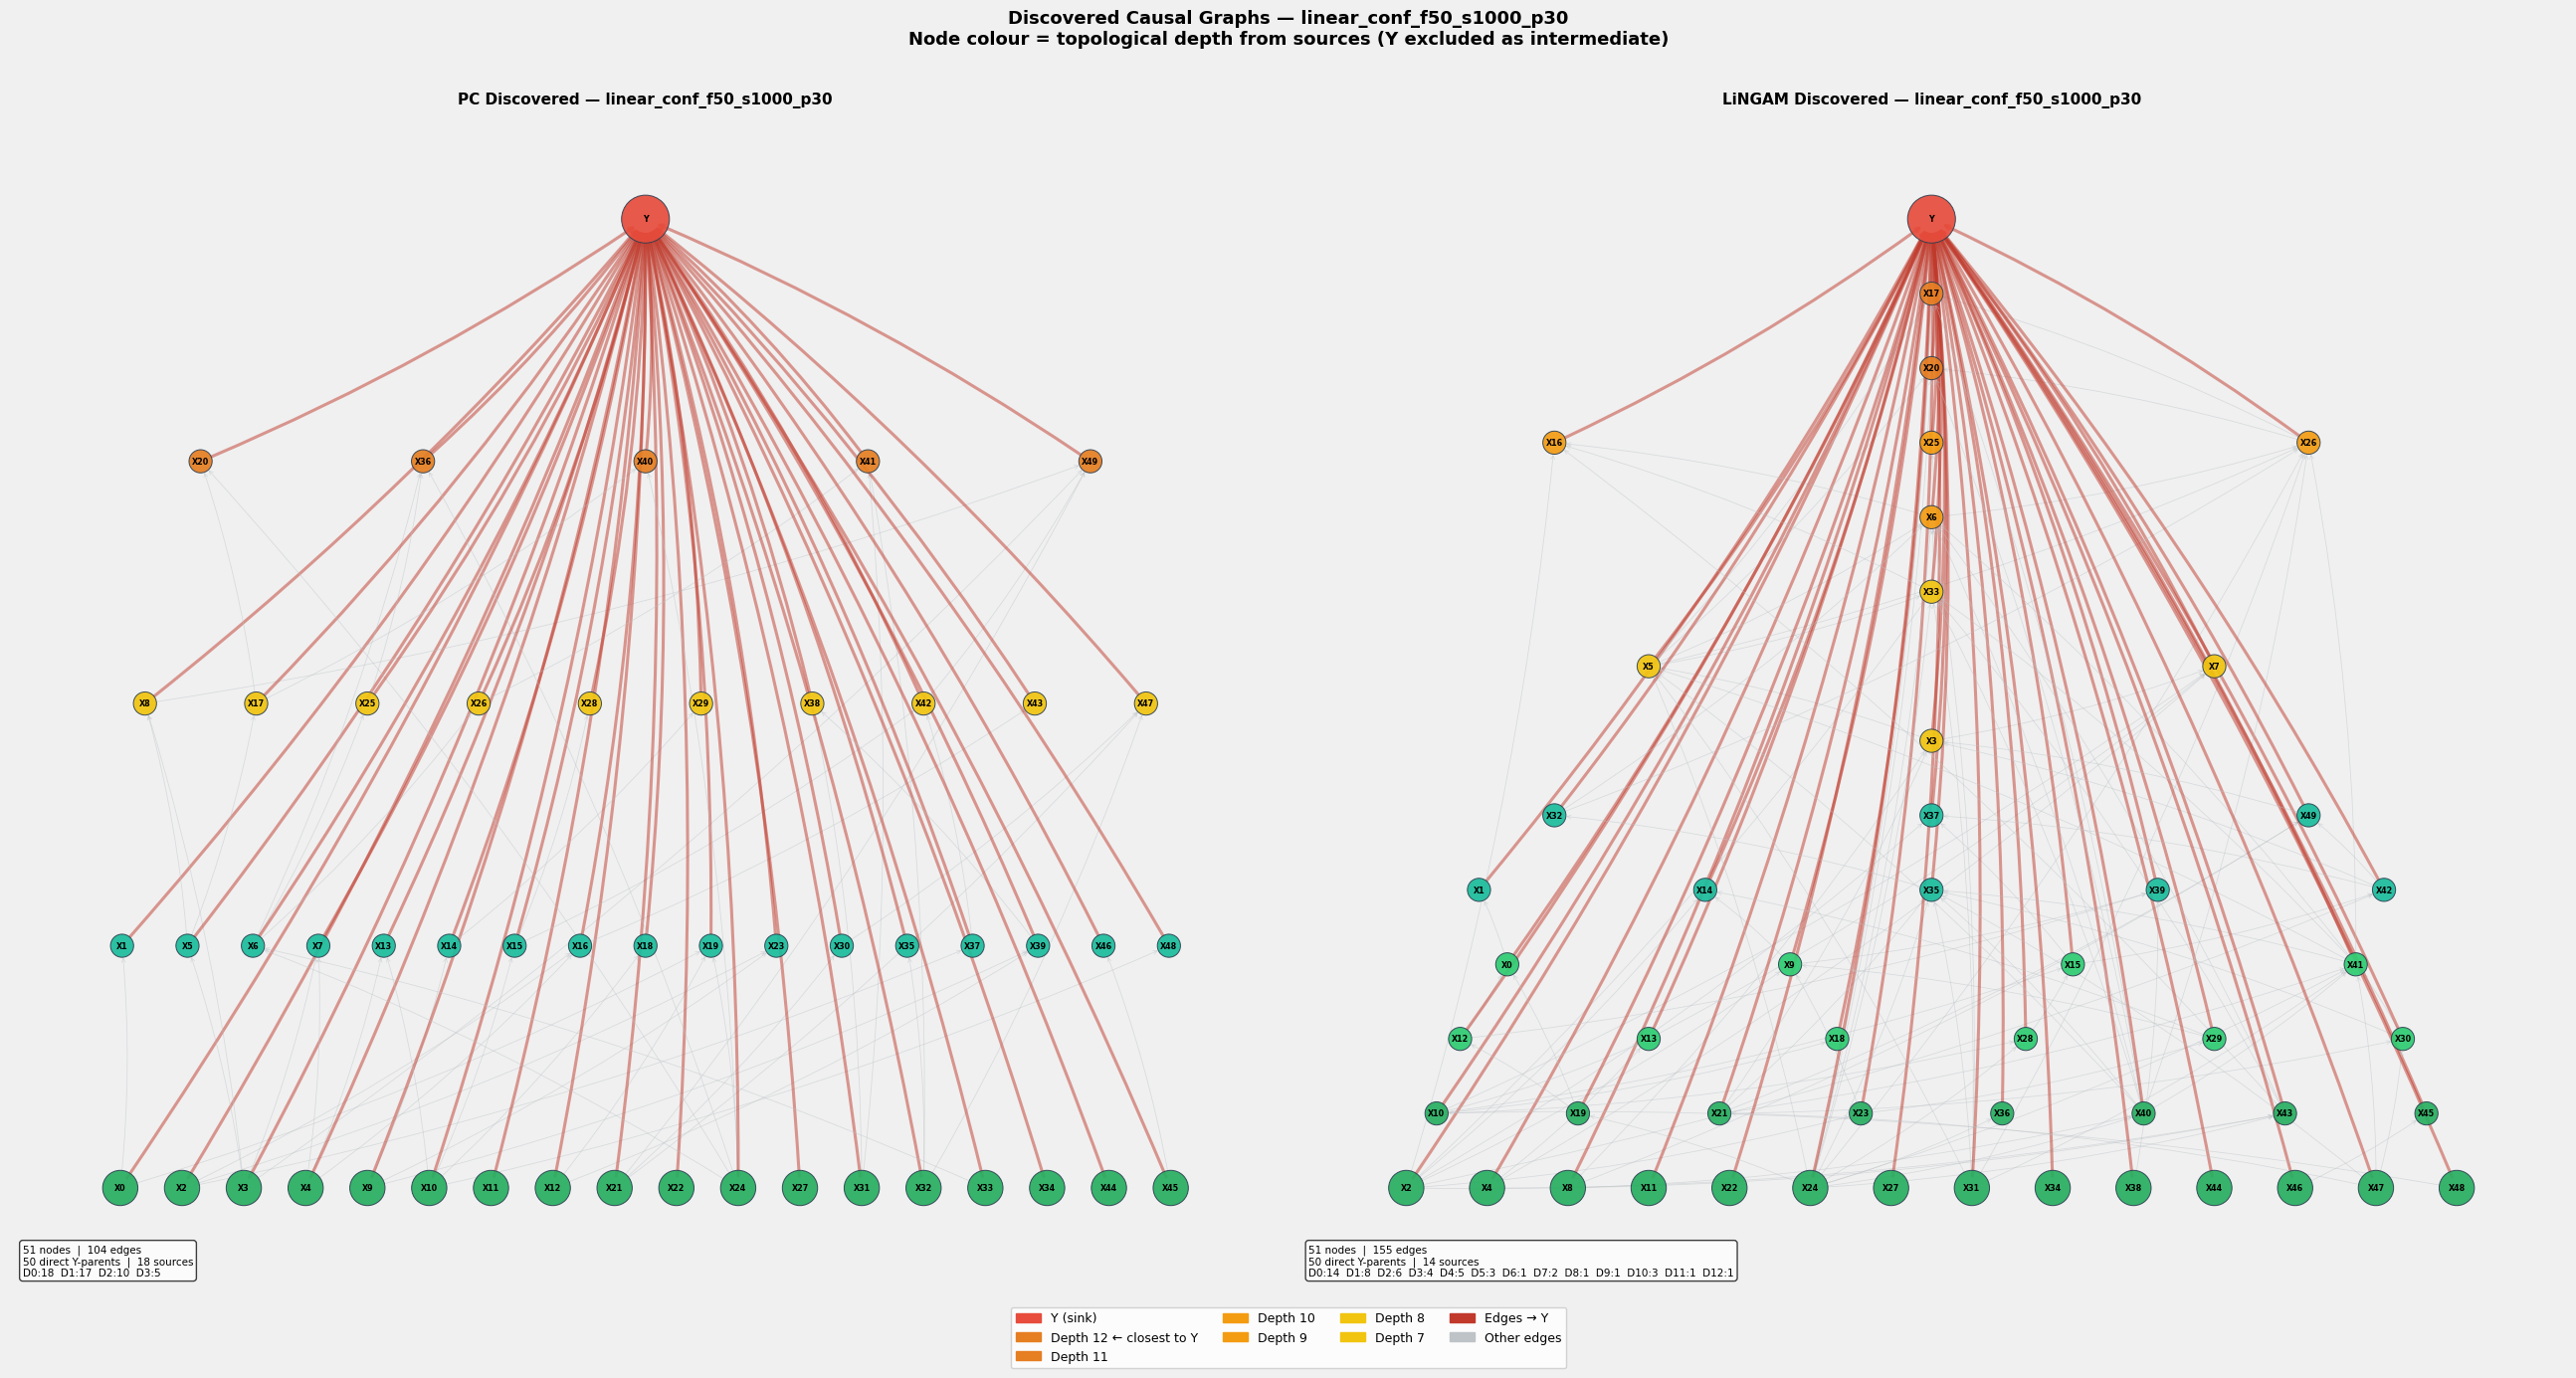

✅  Saved dag_comparison_linear_conf_f50_s1000_p30.png

Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           51        51        51
  Total edges                          137       104       155
  Direct Y-parents                      50        50        50
  Source nodes (depth 0)                10        18        14
  Max topo depth                         7         3        12
  Nodes at depth 0                      10        18        14
  Nodes at depth 1                       9        17         8
  Nodes at depth 2                       9        10         6
  Nodes at depth 3                       8         5         4
  Nodes at depth 4                       7         0         5
  Nodes at depth 5                       4         0         3
  Nodes at depth 6                       2         0         1
  Nodes at depth 7                       1         0      

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ── Load both discovery results + true adjacency for the current DATASET ─────
def load_dag(causal_dir, dataset, method):
    path = causal_dir / f"{dataset}_{method}_results.json"
    with open(path) as f:
        r = json.load(f)
    return np.array(r["adjacency_matrix"]), r["feature_names"]

pc_adj,     pc_names     = load_dag(CAUSAL_DIR, DATASET, "pc")
lingam_adj, lingam_names = load_dag(CAUSAL_DIR, DATASET, "lingam")

# True adjacency: pipeline-constructed full reference graph (X→X causal structure
# + X→Y for every LGBM selected feature + X→Y for every sink node).
# Same (n+1)×(n+1) shape and feature ordering as the discovered adjacencies.
true_adj   = np.load(CAUSAL_DIR / f"{DATASET}_true_full_adjacency.npy")
true_names = pc_names  # same feature ordering (X0…X{n-1}, Y)

# ── Build all three graphs (also used by the True-graph cell below) ───────────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

pos_true   = make_dag_pos(lvg_true,   ml_true)
pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

# ── Draw 2-panel figure: PC | LiNGAM ─────────────────────────────────────────
fig_dags, axes = plt.subplots(1, 2, figsize=(26, 14))
fig_dags.patch.set_facecolor("#f0f0f0")

draw_dag(axes[0], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
         f"PC Discovered — {DATASET}")
draw_dag(axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
         f"LiNGAM Discovered — {DATASET}")

max_lv_disc = max(ml_pc, ml_lingam)
legend_entries = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), max_lv_disc + 1)):
    idx = int(round(prox / max(max_lv_disc, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = max_lv_disc - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == max_lv_disc
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries.append(mpatches.Patch(color=col, label=lbl))
legend_entries += [mpatches.Patch(color="#c0392b", label="Edges → Y"),
                   mpatches.Patch(color="#bdc3c7", label="Other edges")]
fig_dags.legend(handles=legend_entries, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))

fig_dags.suptitle(
    f"Discovered Causal Graphs — {DATASET}\n"
    f"Node colour = topological depth from sources (Y excluded as intermediate)",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.savefig(f"dag_comparison_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved dag_comparison_{DATASET}.png")

# ── Comparison table: True | PC | LiNGAM ─────────────────────────────────────
rows = {}
for label, G, td, src, y_i, ml in [
    ("True",   G_true,   td_true,   src_true,   y_true,   ml_true),
    ("PC",     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ("LiNGAM", G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows[label] = {
        "nodes":      G.number_of_nodes(),
        "edges":      G.number_of_edges(),
        "direct_y":   sum(1 for u, v in G.edges() if v == y_i),
        "sources":    len(src),
        "max_depth":  ml,
        "depth_dist": collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f"{d[key]:>10}"

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print("─" * 64)
print(f"  {'Total nodes':<30}"            + "".join(_fmt(rows[m], "nodes")    for m in ["True","PC","LiNGAM"]))
print(f"  {'Total edges':<30}"            + "".join(_fmt(rows[m], "edges")    for m in ["True","PC","LiNGAM"]))
print(f"  {'Direct Y-parents':<30}"       + "".join(_fmt(rows[m], "direct_y") for m in ["True","PC","LiNGAM"]))
print(f"  {'Source nodes (depth 0)':<30}" + "".join(_fmt(rows[m], "sources")  for m in ["True","PC","LiNGAM"]))
print(f"  {'Max topo depth':<30}"         + "".join(_fmt(rows[m], "max_depth") for m in ["True","PC","LiNGAM"]))
max_d_all = max(rows[m]["max_depth"] for m in rows)
for d in range(max_d_all + 1):
    note = " (closest to Y)" if d == max_d_all else ""
    vals = "".join(f"{rows[m]['depth_dist'].get(d, 0):>10}" for m in ["True","PC","LiNGAM"])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

# ── Edge recovery metrics (vs true_full_adjacency) ────────────────────────────

pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

print(f"\n{'Edge Recovery vs true_full_adj':<32} {'PC':>10} {'LiNGAM':>10}")
print("─" * 54)
print(f"  {'Precision':<30} {pc_prec:>10.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<30} {pc_rec:>10.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<30} {pc_f1:>10.3f} {lingam_f1:>10.3f}")


### 6.1. True Causal Graph

Ground-truth DAG for comparison against the discovered PC and LiNGAM graphs above.

  ✅  Saved → plots/linear_conf_f50_s1000_p30/dag_true_linear_conf_f50_s1000_p30.png


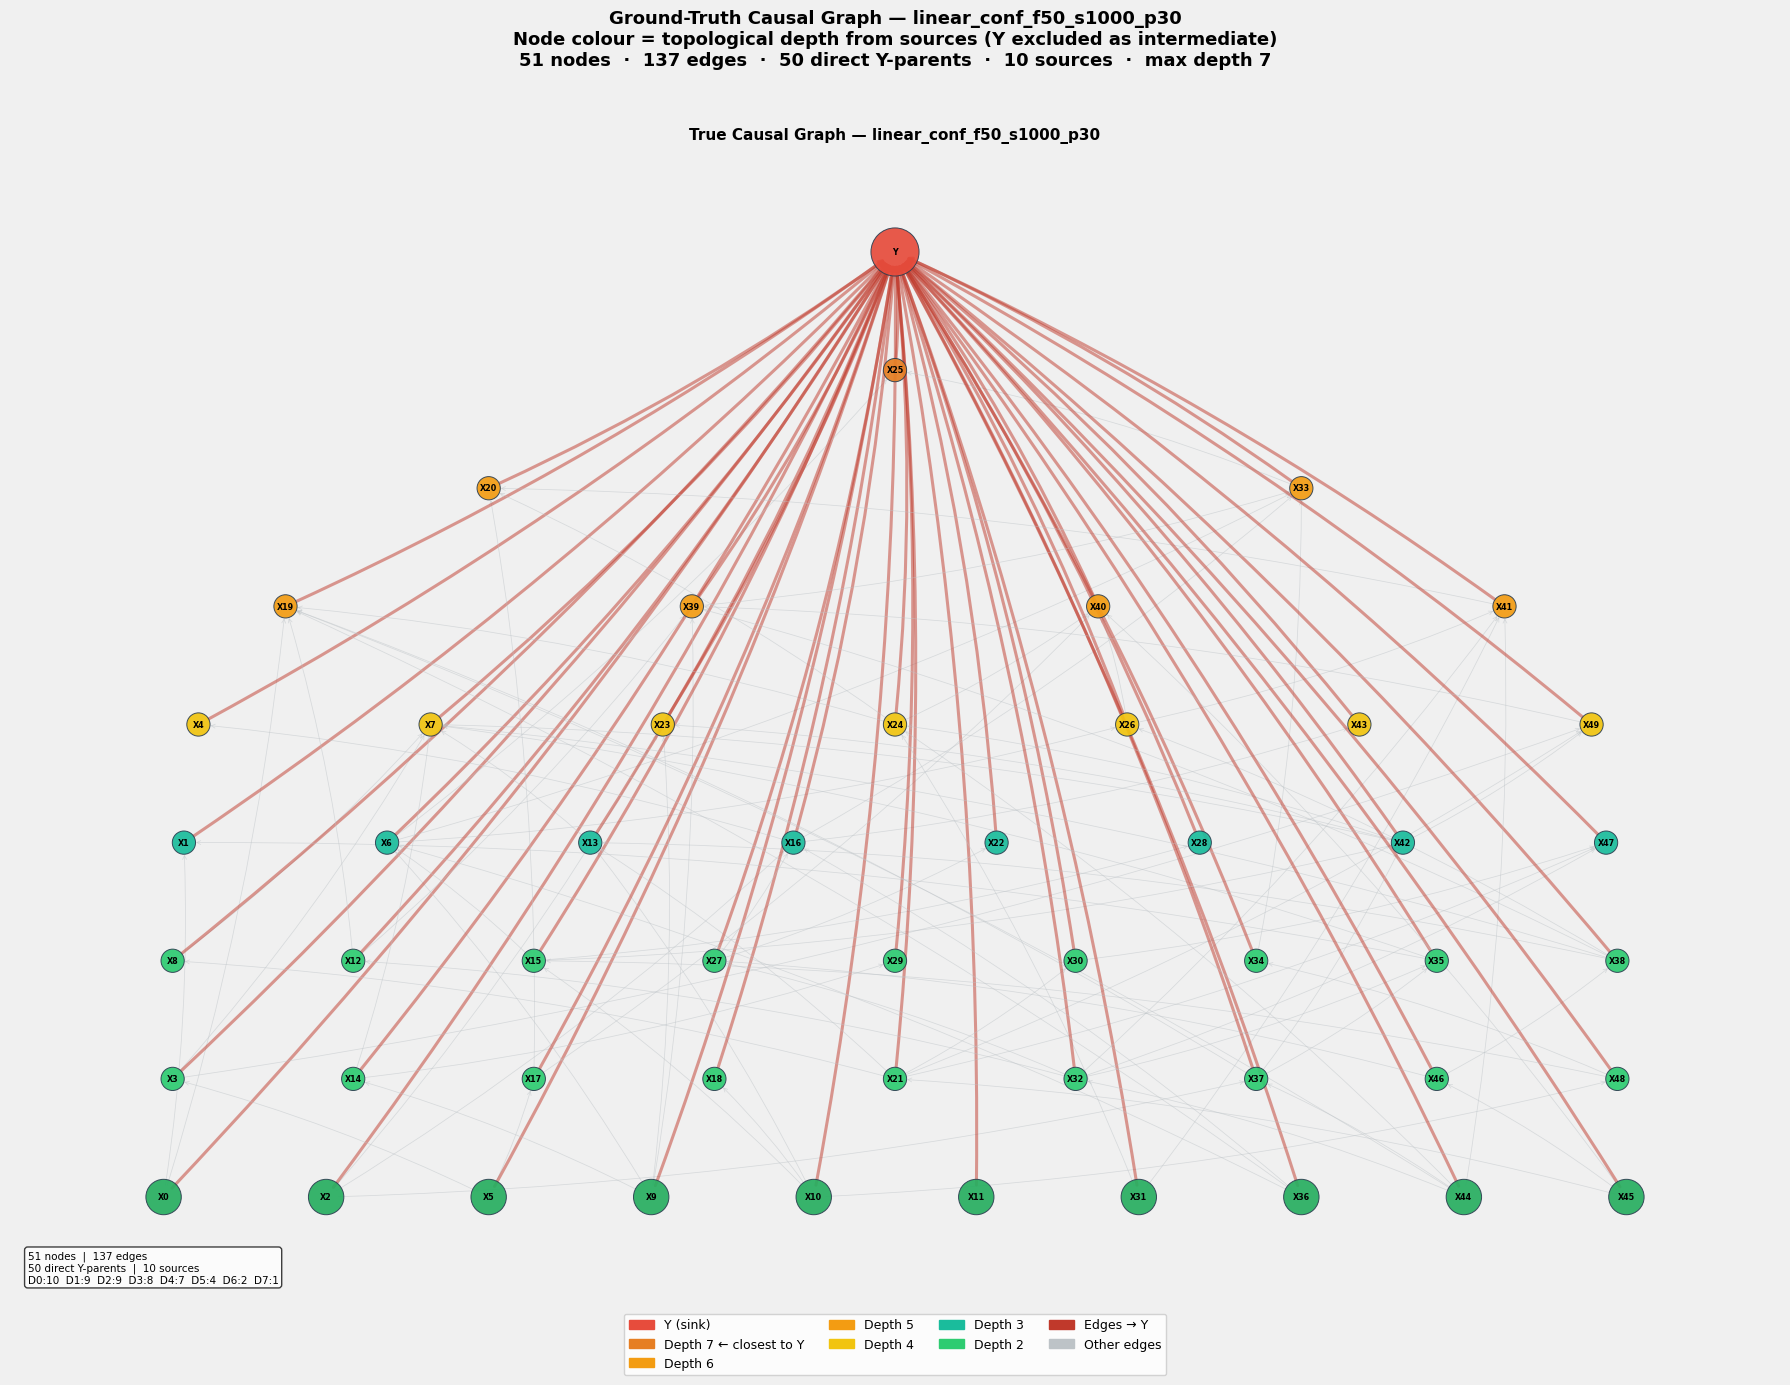

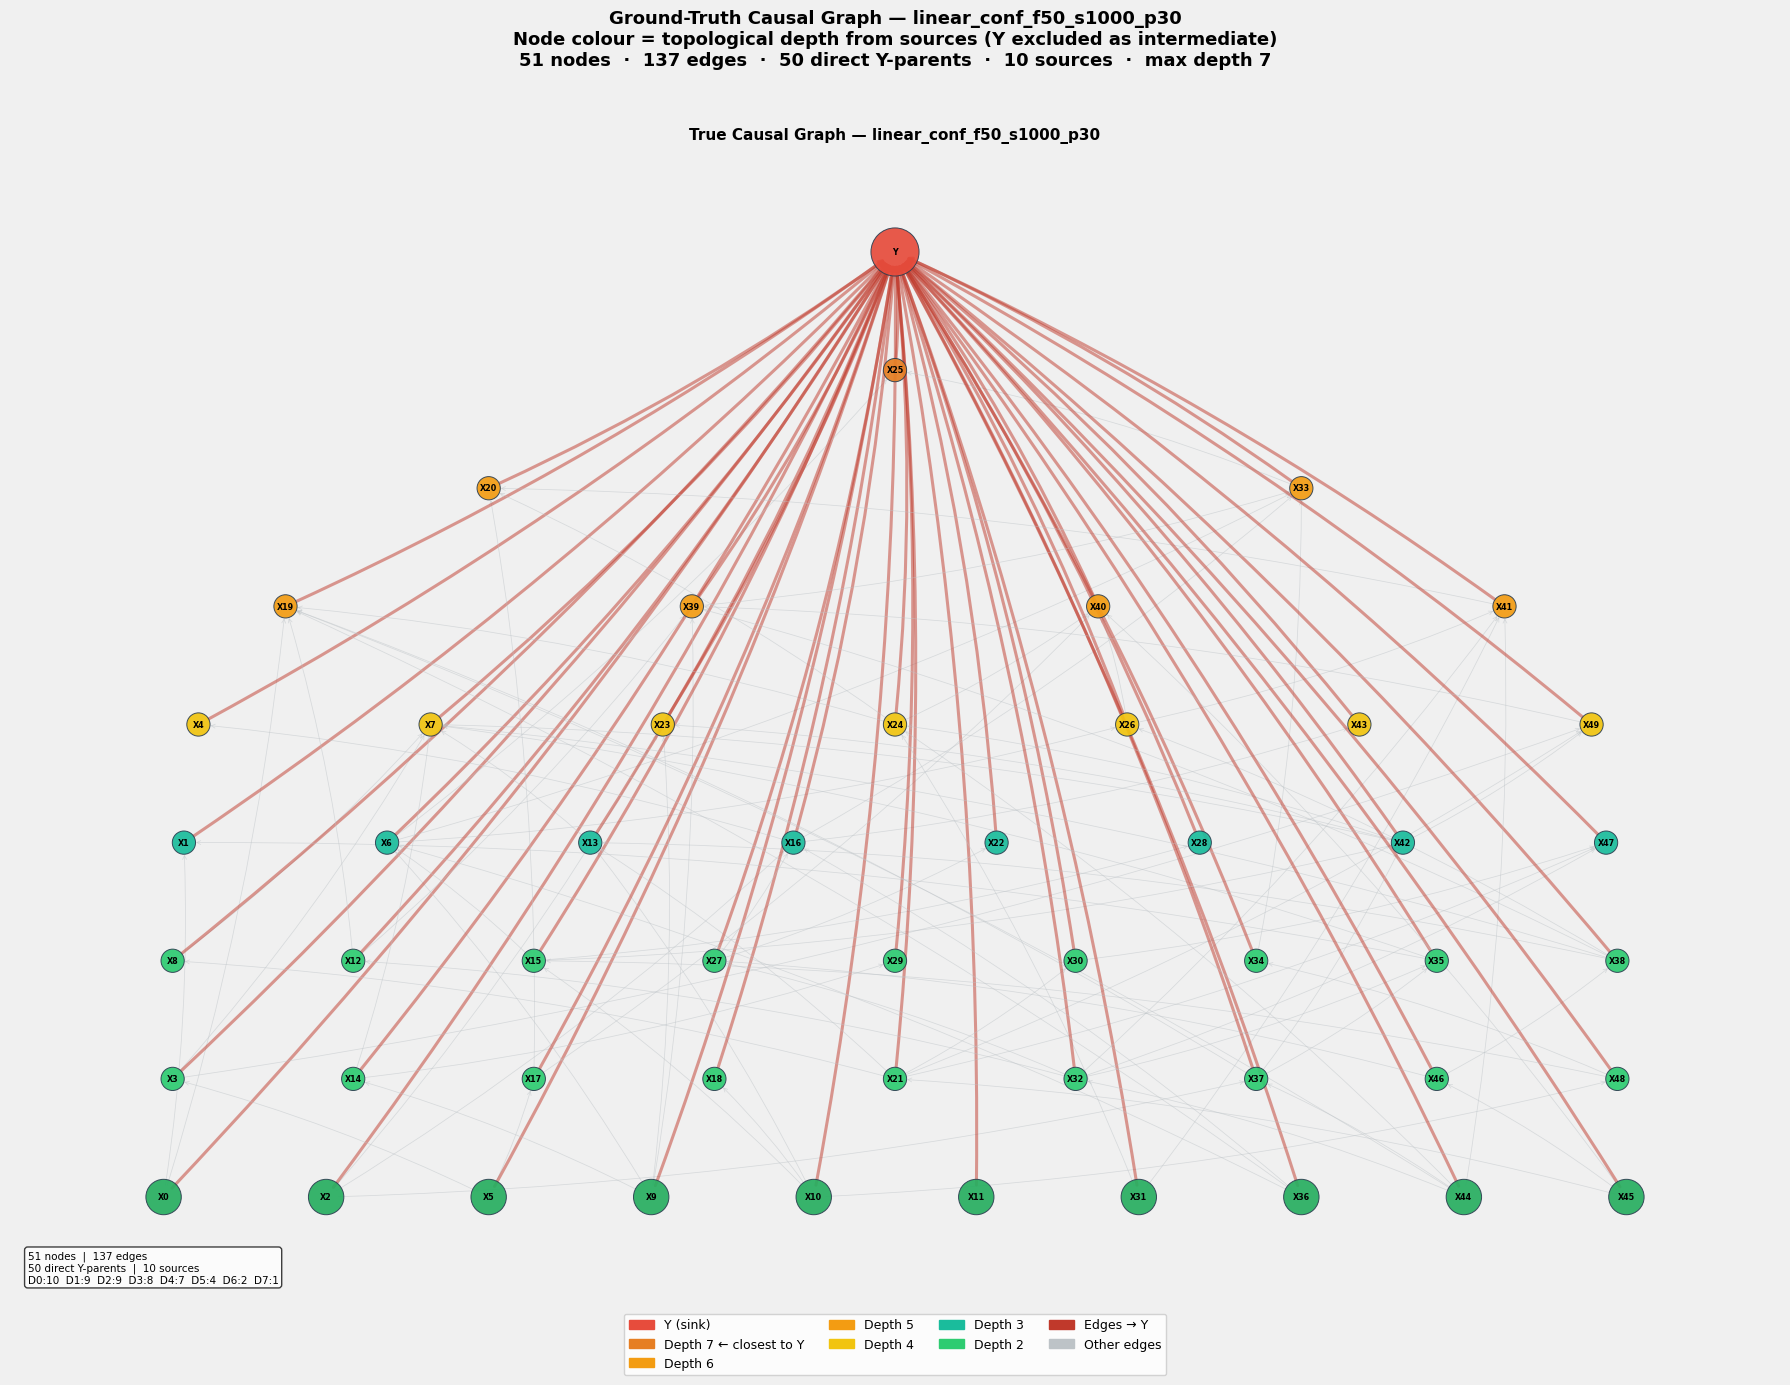

In [10]:
plot_true_dag(
    G_true, pos_true, td_true, src_true, y_true, ml_true,
    DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
)


## 7. DAG Node Highlight: PC vs LiNGAM

Highlight a specific feature node in both PC and LiNGAM graphs to understand its causal role.  
**Blue** arrows = incoming edges (parents of the node).  
**Orange-red** arrows = outgoing edges (children of the node).  
All other nodes and edges are muted so the focal node stands out clearly.

In/out degree and topological depth are annotated at the bottom-left of each panel.  
Use this after the Graph Sensitivity Analysis (Section 9) to inspect features with high GSS, low SSS, or large rank shifts.

  ✅  Saved → plots/linear_conf_f50_s1000_p30/dag_highlight_X33_linear_conf_f50_s1000_p30.png


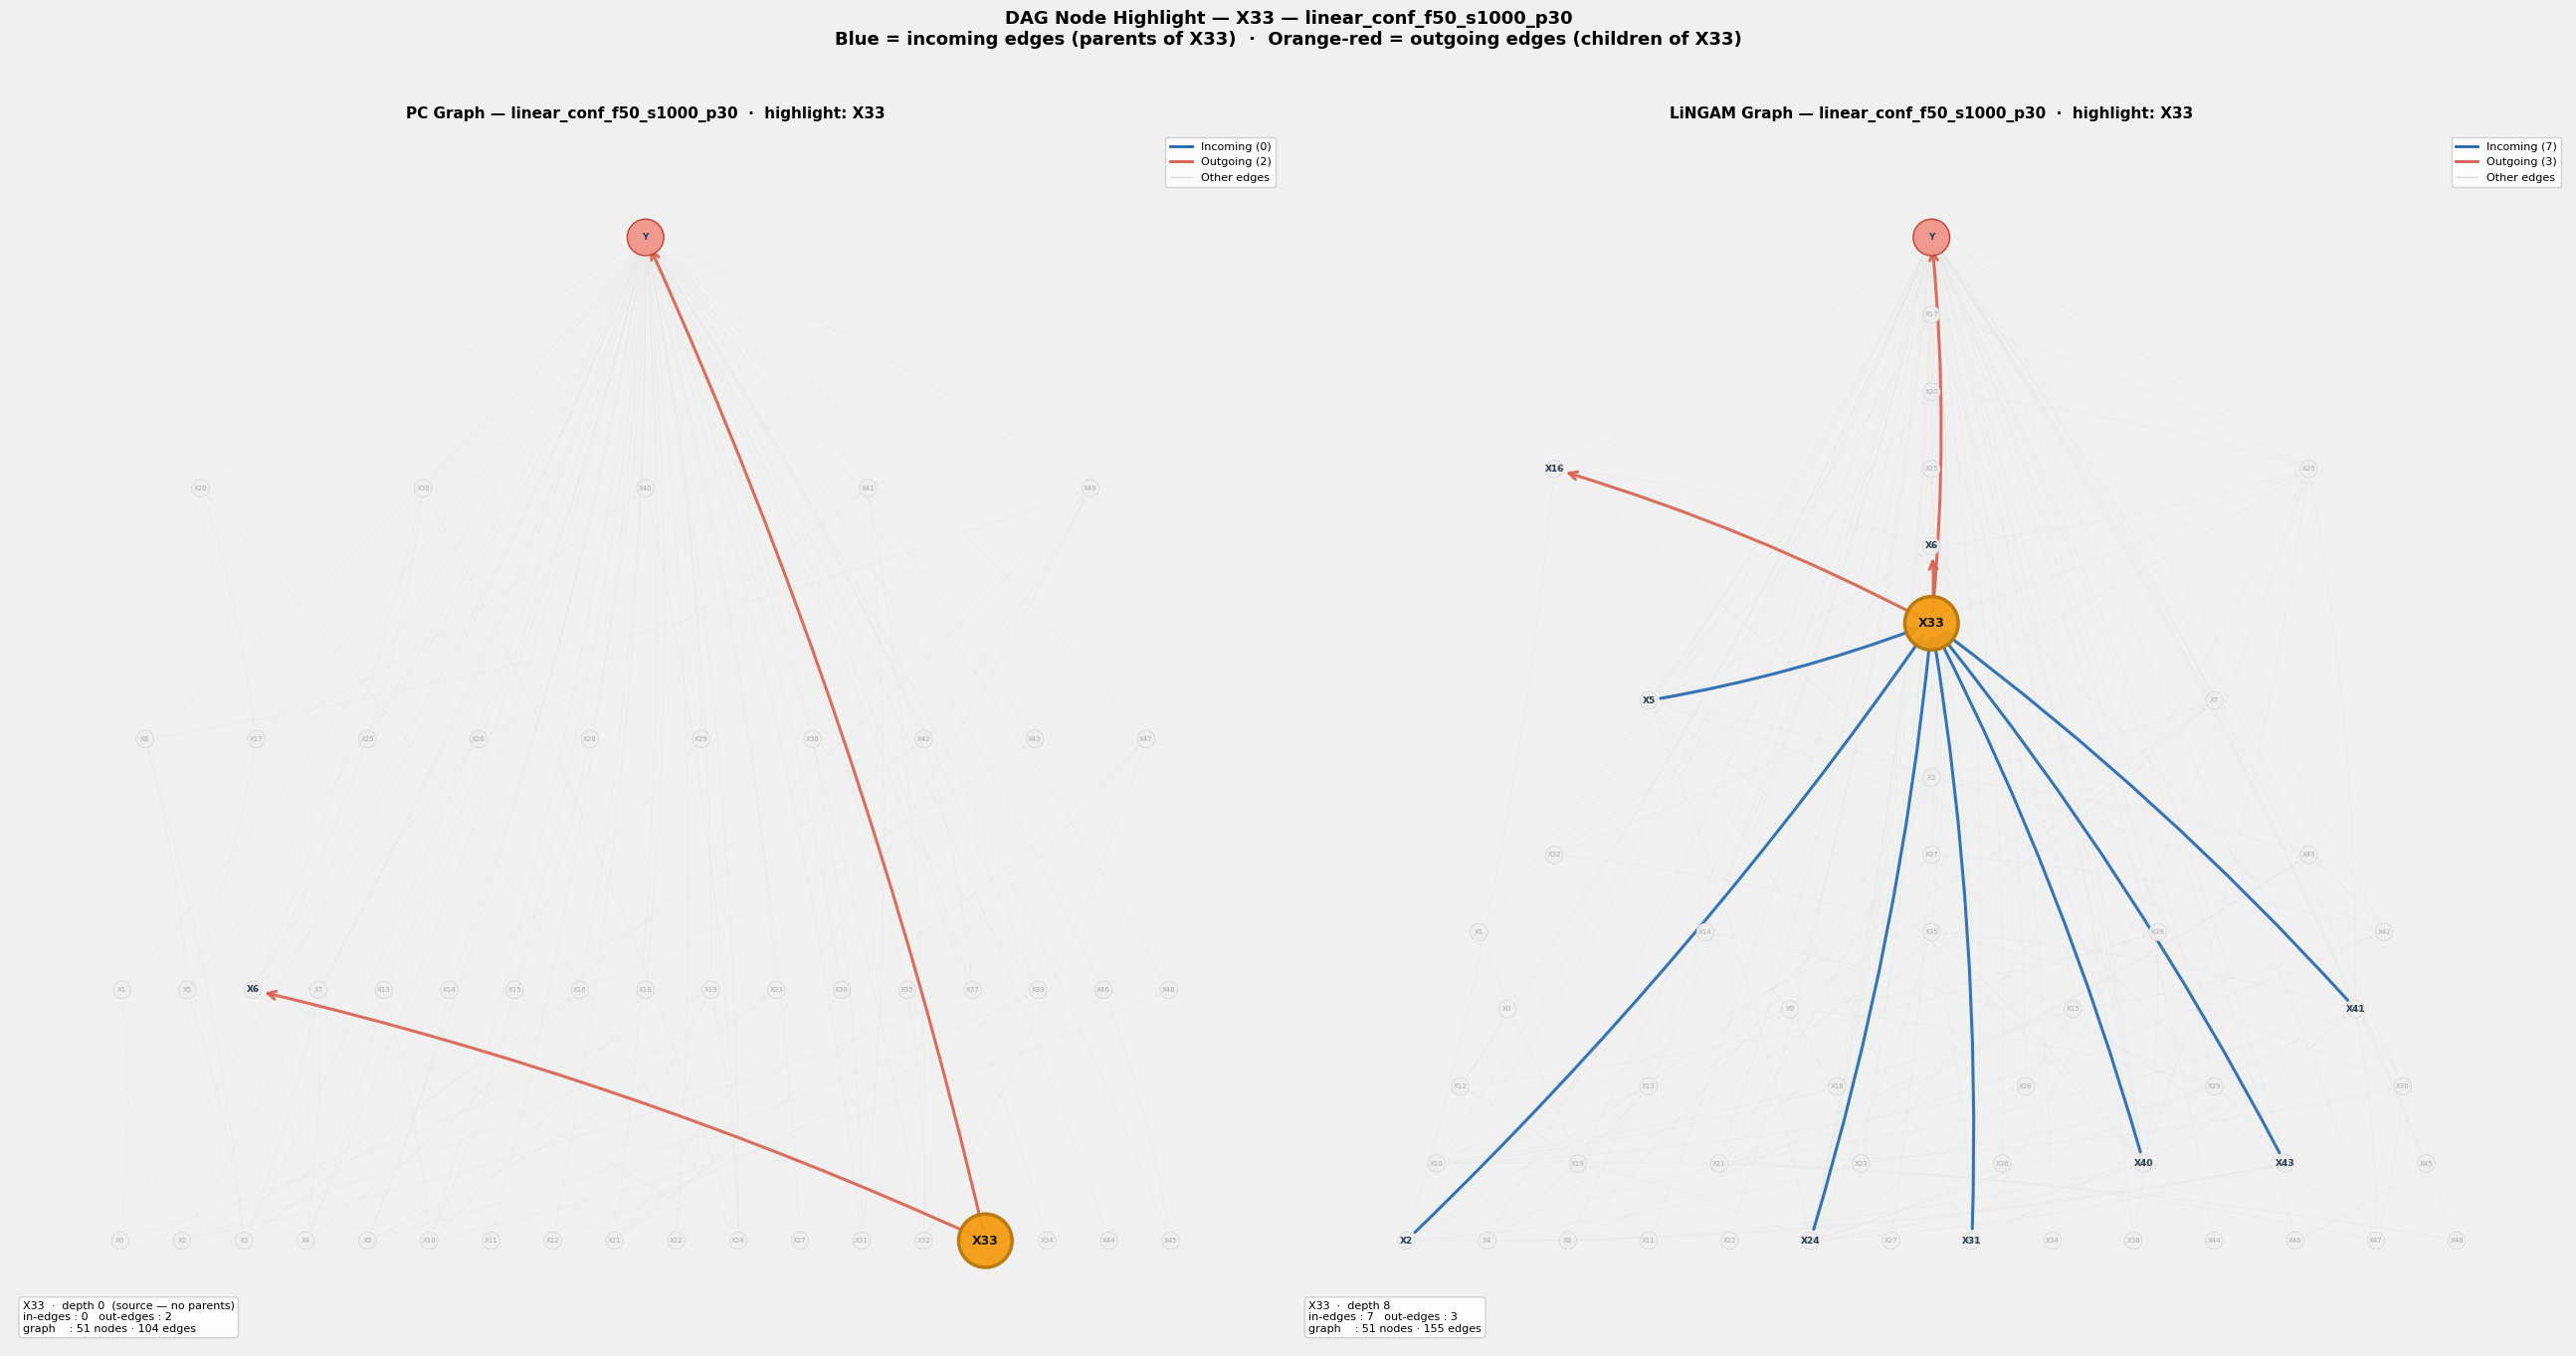

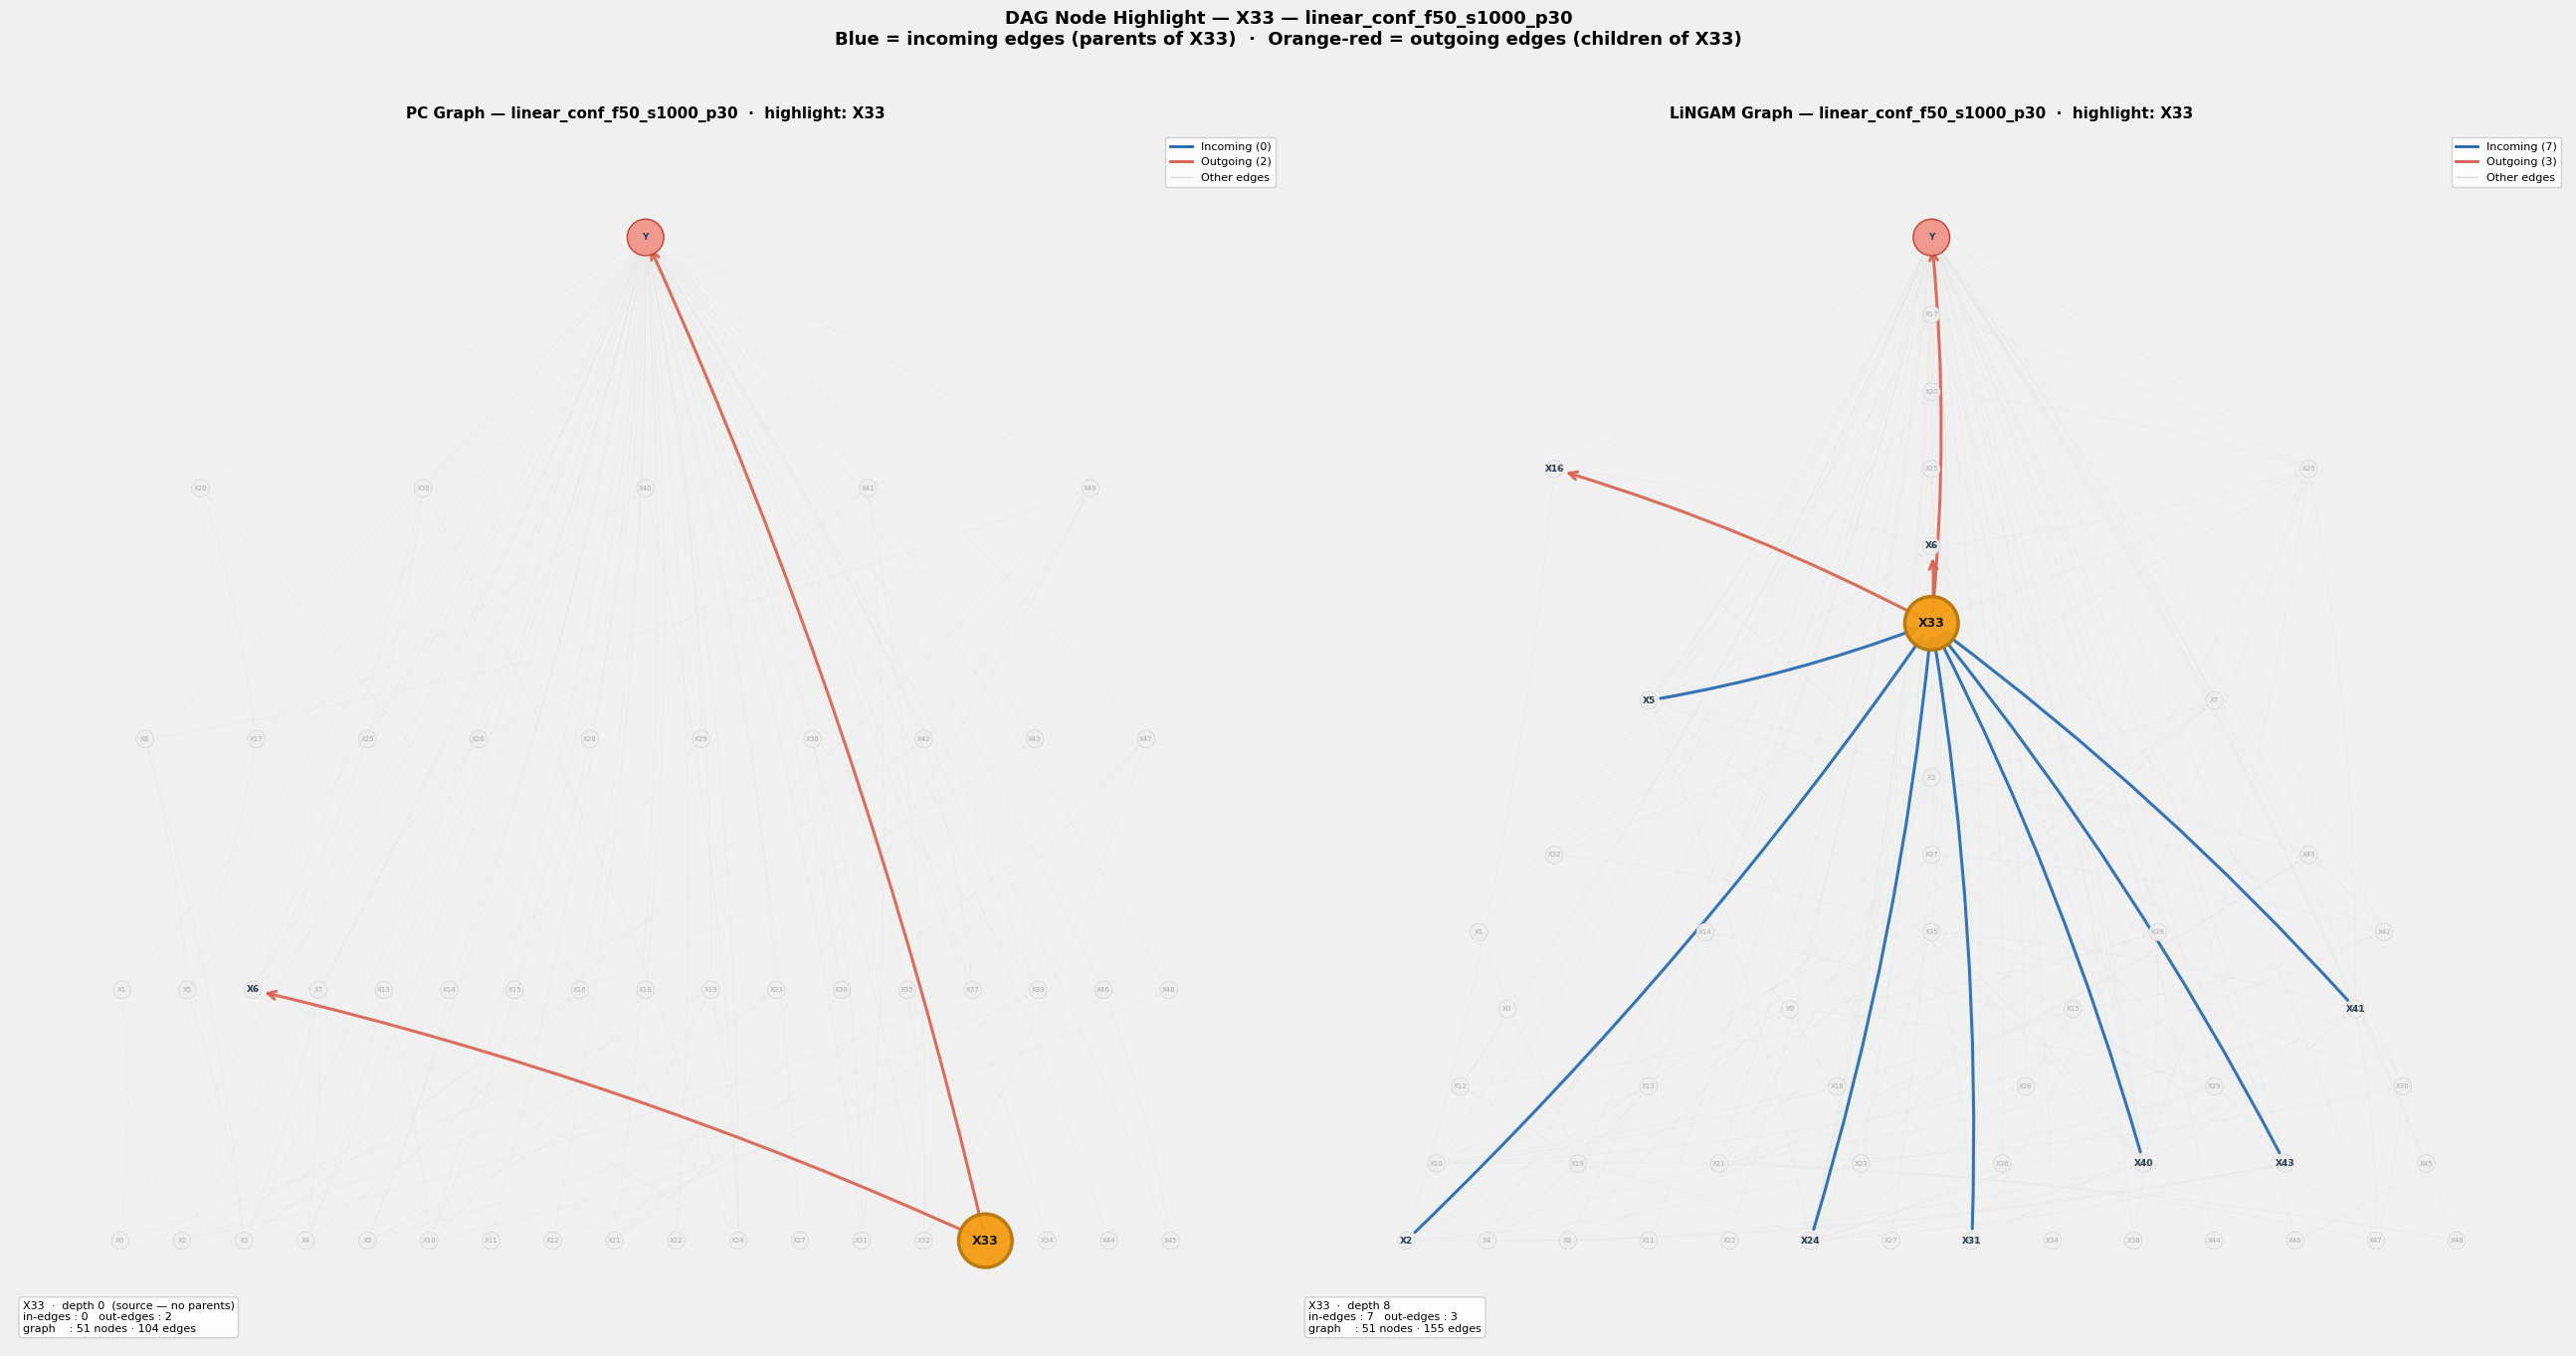

In [11]:
plot_dag_highlight(
    G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
    G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
    "X33", pc_names, DATASET, save_dir=PLOTS_DIR,
)


### 7.1. SHAP Attribution Comparison: PC vs LiNGAM

Instance-level bar charts and scatter plots comparing Shapley attributions under PC and LiNGAM graphs for the selected features. Columns: Traditional (no graph) | Method (PC) | Method (LiNGAM) | Method (True DAG).

In [12]:
features_names = ["X33", "X41", "X47", "X7", "X24"]
fig_instance_pc_vs_lingam = plot_instance_shap_pc_vs_lingam(
    shap_data, feature_names, scratch_rank, top_features, instance_idx,
    pc_edges, lingam_edges, DATASET, N_TOP_FEATURES,
    features=features_names,
)

In [13]:
fig_scatter_pc_vs_lingam = plot_shap_scatter_pc_vs_lingam(
    shap_data, feature_names, scratch_rank, top_features, x_test,
    pc_edges, lingam_edges, DATASET, N_TOP_FEATURES,
    features=features_names,
)

## 8. True DAG Node Highlight

Same highlight visualisation as Section 7 but drawn on the **ground-truth causal graph**.  
Use this alongside the PC / LiNGAM highlights to compare the node's true causal neighbourhood
against what each discovery algorithm found.

**Blue** arrows = incoming edges (parents of the node).  
**Orange-red** arrows = outgoing edges (children of the node).  
All other nodes and edges are muted.

  ✅  Saved → plots/linear_conf_f50_s1000_p30/dag_highlight_true_X29_linear_conf_f50_s1000_p30.png


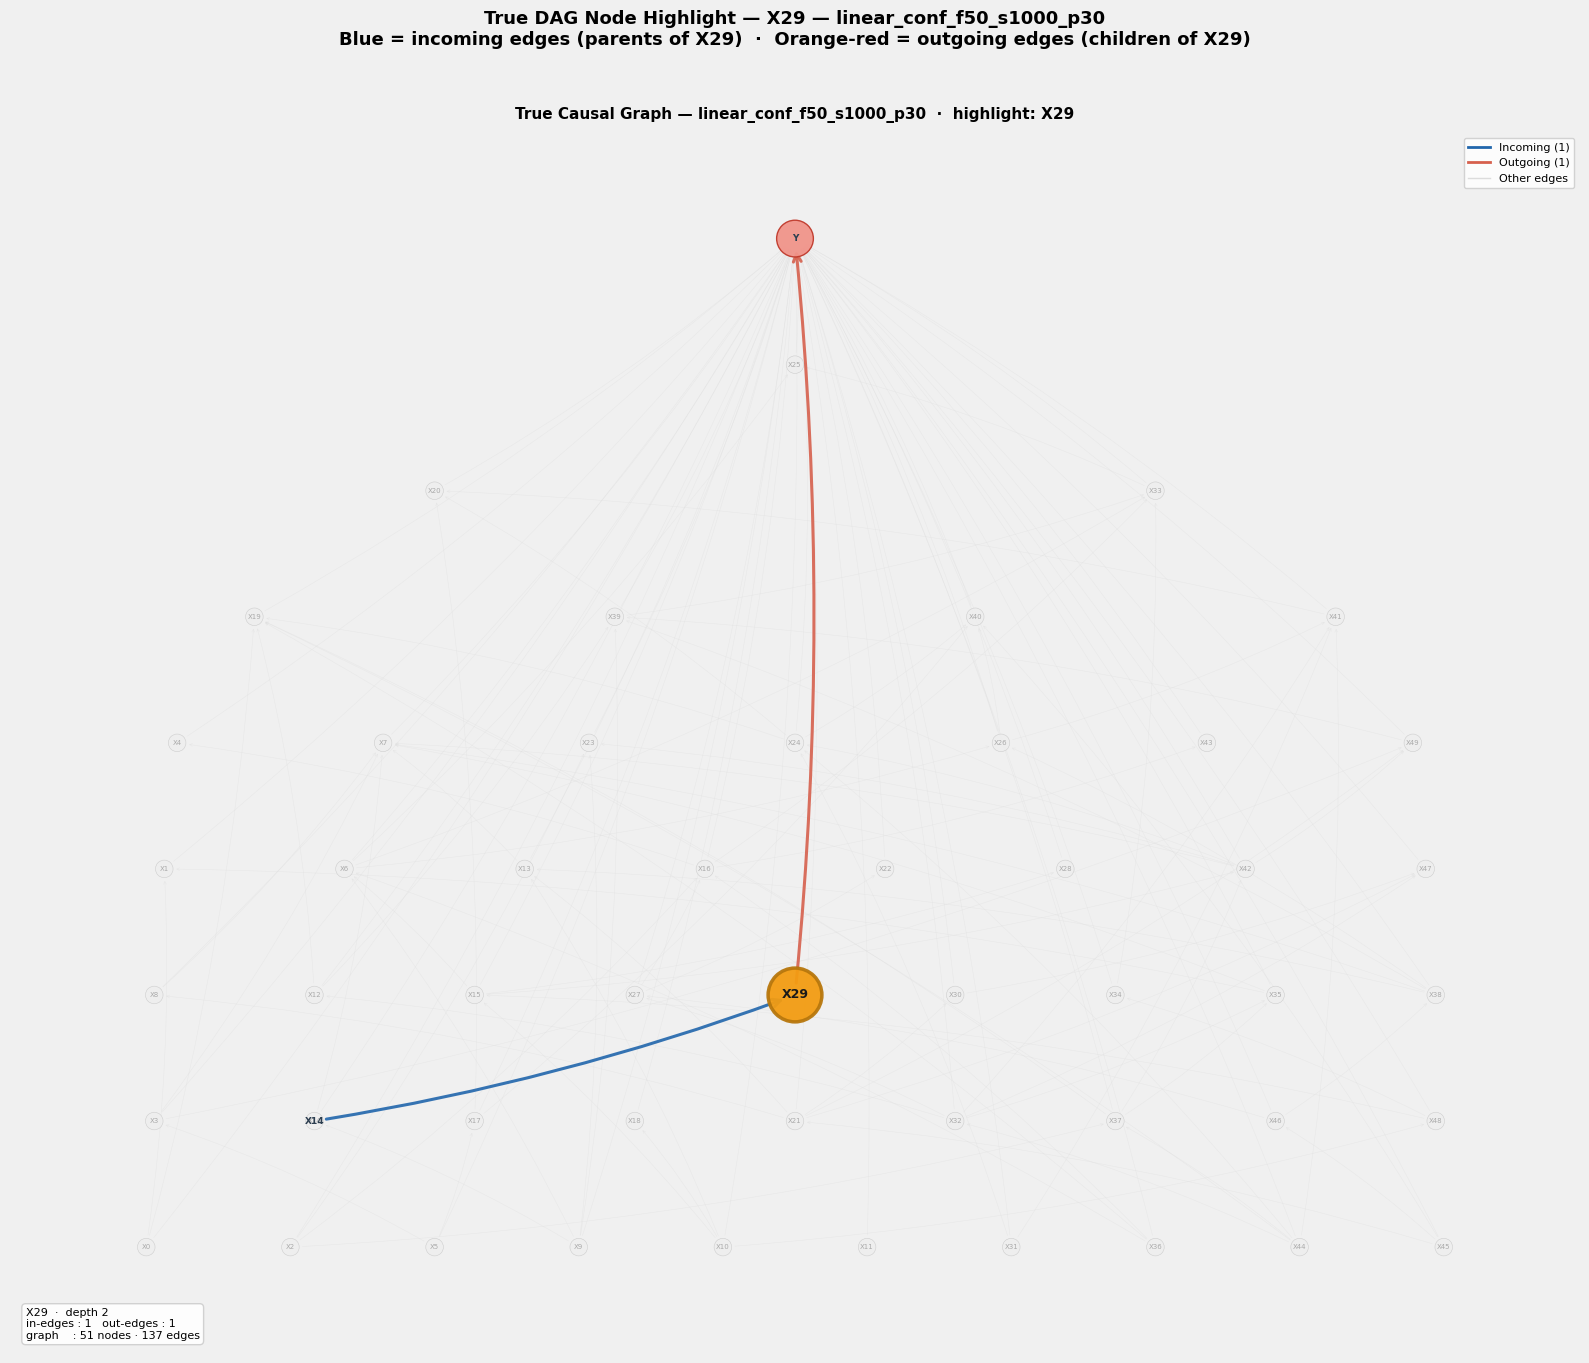

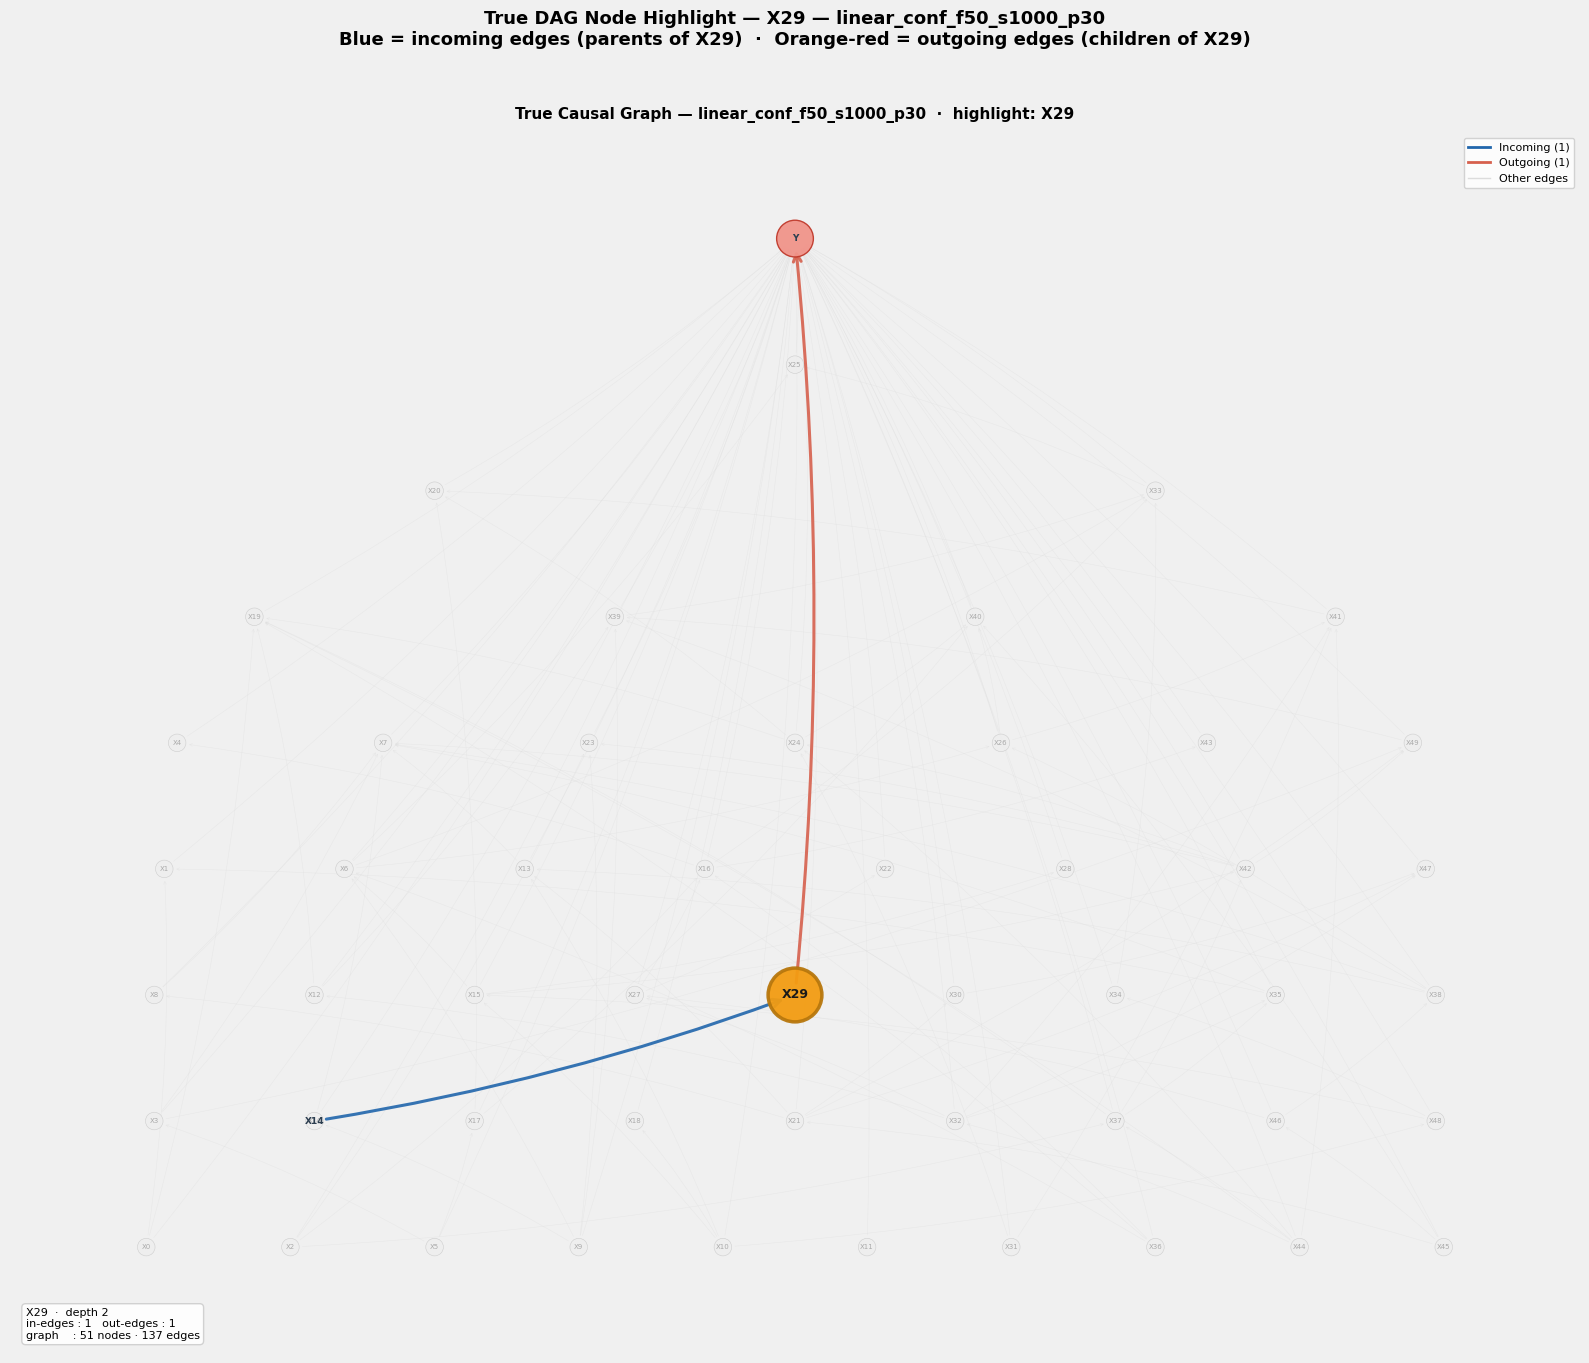

In [14]:
plot_dag_highlight_true(
    G_true, pos_true, td_true, src_true, y_true, ml_true,
    "X29", true_names, DATASET, save_dir=PLOTS_DIR,
)


## 9. Graph Sensitivity Analysis

**Goal**: quantify how much the choice of discovered graph (PC vs LiNGAM vs ground truth) changes the attributions produced by each causal Shapley method. This lets us answer the key thesis question:

> *Which method is causally aware but robust to graph quality?*

### Strategy

| Step | Metric | Graph variants | Instances used |
|------|--------|----------------|----------------|
| 9.1 | Load pre-computed Shapley values from pipeline output | All (PC / LiNGAM / True) | All pipeline test instances (~100) |
| 9.2 | **Graph Sensitivity Score (GSS)** — importance-magnitude change between PC and LiNGAM | PC vs LiNGAM | All pre-computed instances |
| 9.3 | **Ranking Robustness** — Spearman ρ, Top-K Jaccard, True-parent Precision@K | PC vs LiNGAM vs True | All pre-computed instances |
| 9.4 | **Sign Stability Score (SSS)** — sign agreement between PC and LiNGAM attributions | PC vs LiNGAM | All pre-computed instances |
| 9.5 | **Recommendation summary** — aggregated score per method | All variants | — |

> **Run Section 3 first** (cells through "Load Shapley Values") to populate `shap_data`, `feature_names`, `x_test`, etc.

### 9.1. Load SHAP Values (All Methods × Graphs)

Load pre-computed Shapley values for all combinations of causal method (Asymmetric, Causal, Flow) × graph (PC, LiNGAM, True) from pipeline output. No re-computation is required.

In [15]:
"""
10.1 — Load pre-computed Shapley values (all 3 methods × 3 graphs) from pipeline output.

The pipeline (calculate_all_shapley_values) already computed and saved every combination
to data/explainability/{DATASET}/lgbm/{graph}/{method}/shapley_values.npy.
No re-computation or caching is needed here.
"""
_exp_base = EXPLAINABILITY_DIR / DATASET / "lgbm"

PIPELINE_KEYS = {
    "Asymmetric (PC)":     _exp_base / "pc"     / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":         _exp_base / "pc"     / "causal"     / "shapley_values.npy",
    "Flow (PC)":           _exp_base / "pc"     / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)": _exp_base / "lingam" / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":     _exp_base / "lingam" / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":       _exp_base / "lingam" / "flow"       / "shapley_values.npy",
    "Asymmetric (True)":   _exp_base / "true"   / "asymmetric" / "shapley_values.npy",
    "Causal (True)":       _exp_base / "true"   / "causal"     / "shapley_values.npy",
    "Flow (True)":         _exp_base / "true"   / "flow"       / "shapley_values.npy",
}

subset_shap_data = {}
for key, path in PIPELINE_KEYS.items():
    if path.exists():
        subset_shap_data[key] = np.load(path)
    else:
        print(f"⚠️  Missing: {path}")

# ── Auxiliary variables expected by downstream cells ─────────────────────────
_train_tmp    = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_train.parquet")
_test_tmp     = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
feat_names_10 = [c for c in _train_tmp.drop(columns=["Y"]).columns]

X_train_10 = _train_tmp.drop(columns=["Y"]); y_train_10 = _train_tmp["Y"]
X_test_10  = _test_tmp.drop(columns=["Y"]);  y_test_10  = _test_tmp["Y"]

RANDOM_STATE_10 = 42
N_TRUE_INSTANCES = list(subset_shap_data.values())[0].shape[0]

true_adj_xx         = true_adj[:len(feat_names_10), :len(feat_names_10)]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f"{DATASET}_pc_train_adjacency.npy")
lingam_train_adj_xx = np.load(CAUSAL_DIR / f"{DATASET}_lingam_train_adjacency.npy")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"✅  Loaded {len(subset_shap_data)} arrays from pipeline output.")
print(f"    Instances per array: {N_TRUE_INSTANCES}  |  Features: {list(subset_shap_data.values())[0].shape[1]}\n")
print(f"{'Key':<28}  {'Shape':>14}  {'mean|φ|':>9}  {'zeros%':>7}")
print("─" * 65)
for k, v in subset_shap_data.items():
    print(f"  {k:<26}  {str(v.shape):>14}  {np.abs(v).mean():>9.4f}  {100*(v==0).mean():>6.1f}%")


✅  Loaded 9 arrays from pipeline output.
    Instances per array: 100  |  Features: 50

Key                                    Shape    mean|φ|   zeros%
─────────────────────────────────────────────────────────────────
  Asymmetric (PC)                  (100, 50)     0.2324     0.0%
  Causal (PC)                      (100, 50)     0.3130     0.0%
  Flow (PC)                        (100, 50)     0.2722    11.1%
  Asymmetric (LiNGAM)              (100, 50)     0.2329     0.2%
  Causal (LiNGAM)                  (100, 50)     0.3061     0.0%
  Flow (LiNGAM)                    (100, 50)     0.2609     9.4%
  Asymmetric (True)                (100, 50)     0.2321     0.0%
  Causal (True)                    (100, 50)     0.3348     0.0%
  Flow (True)                      (100, 50)     0.2379     7.5%


"""
9.2 — Graph Sensitivity Score (GSS): PC vs LiNGAM

GSS(method, feature) = mean_i ( |φ(PC,i,f)| - |φ(LiNGAM,i,f)| )

No outer absolute, no normalisation — the sign encodes direction:
→ GSS > 0 : PC assigns higher mean absolute importance for this feature.
→ GSS < 0 : LiNGAM assigns higher mean absolute importance for this feature.
→ GSS ≈ 0 : both graphs agree on magnitude for this feature.

**Note:** Metrics already computed in section 4. Using pre-computed `gss_feat` and `feat_delta`.
"""

In [16]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed gss_feat and feat_delta

for meth in BASE_METHODS:
    if meth not in gss_feat:
        continue
    g = gss_feat[meth]
    print(f"{meth}: mean GSS = {np.mean(g):.4f}  "
          f"min GSS = {np.min(g):.4f}  max GSS = {np.max(g):.4f}")

# ── A: Feature-level GSS heatmap ──────────────────────────────────────────────
fig_gss_hmap = plot_gss_heatmap(
    gss_feat, feature_names, BASE_METHODS, DATASET, save_dir=PLOTS_DIR,
)

# ── B: Per-instance magnitude delta box plots (top-N Scratch features) ────────
fig_delta = plot_gss_delta_box(
    feat_delta, feature_names, scratch_rank, METHOD_COLORS,
    DATASET, N_TOP_FEATURES, save_dir=PLOTS_DIR,
)

# ── C: Method-level GSS summary ───────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean GSS':>10}  {'Median GSS':>11}  {'Max |GSS|':>10}  "
      f"{'Feat |GSS|>0.5':>14}  {'Feat |GSS|>0.1':>14}")
print("─" * 85)
for meth in BASE_METHODS:
    if meth not in gss_feat:
        continue
    g = gss_feat[meth]
    print(f"  {meth:<13}  {np.mean(g):>10.4f}  {np.median(g):>11.4f}  "
          f"{np.max(np.abs(g)):>10.4f}  {(np.abs(g)>0.5).sum():>14d}  {(np.abs(g)>0.1).sum():>14d}")

Asymmetric: mean GSS = -0.0005  min GSS = -0.0858  max GSS = 0.0535
Causal: mean GSS = 0.0070  min GSS = -0.9103  max GSS = 0.7625
Flow: mean GSS = 0.0112  min GSS = -1.2893  max GSS = 1.7085


  ✅  Saved → plots/linear_conf_f50_s1000_p30/gss_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/gss_delta_box_linear_conf_f50_s1000_p30.png

Method             Mean GSS   Median GSS   Max |GSS|  Feat |GSS|>0.5  Feat |GSS|>0.1
─────────────────────────────────────────────────────────────────────────────────────
  Asymmetric        -0.0005      -0.0002      0.0858               0               0
  Causal             0.0070       0.0030      0.9103               7              24
  Flow               0.0112      -0.0004      1.7085               4              24


### 9.3. Ranking Robustness & True-Parent Recovery

Spearman rank correlation between each method's feature ranking and the Scratch baseline, Top-K Jaccard overlap, and true-parent Precision@K — measuring how faithfully the discovered graph preserves causal feature rankings relative to the ground truth.

In [17]:
"""
9.3 — Ranking robustness vs Scratch & True-parent recovery

A) Spearman ρ  — rank corr of mean|φ| per feature: each method+graph vs Scratch
B) Top-K Jaccard vs Scratch — feature set overlap with the graph-free baseline
C) True-parent Precision@K — how many of the top-K features are real Y-parents?
"""
from scipy.stats import spearmanr

K_VALUES = [5, 10, 20]

# ── Load true Y-parent set ────────────────────────────────────────────────────
with open(SYNTHETIC_DIR / f"{DATASET}_metadata.json") as _f:
    _meta = json.load(_f)
y_parent_set = set(_meta["y_parent_indices"])
print(f"True Y-parents: {len(y_parent_set)} / {len(feature_names)} features")
print(f"Random baseline precision: {len(y_parent_set)/len(feature_names):.3f}")

scratch_ma = mean_abs_shap(shap_data, "Scratch")

# ── A: Spearman ρ — each method × graph vs Scratch ───────────────────────────
spearman_data = {}
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        rho, _ = spearmanr(mean_abs_shap(shap_data, k), scratch_ma)
        spearman_data[(meth, g)] = float(rho)

fig_spearman = plot_spearman_heatmap(
    spearman_data, BASE_METHODS, DISC_GRAPHS, DATASET, n_shap, save_dir=PLOTS_DIR,
)

# ── B: Top-K Jaccard vs Scratch ───────────────────────────────────────────────
jaccard_rows = []
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        for kv in K_VALUES:
            j = top_k_jaccard(mean_abs_shap(shap_data, k), scratch_ma, kv)
            jaccard_rows.append(dict(Method=meth, Graph=g, K=f"Top-{kv}", Jaccard=j))

df_jacc = pd.DataFrame(jaccard_rows)
fig_jacc = plot_jaccard_bar(df_jacc, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

# ── C: True-parent Precision@K ───────────────────────────────────────────────
random_baseline = len(y_parent_set) / len(feature_names)

parent_rows = []
for meth_key, meth_label in [("Scratch", "Scratch")] + \
                              [(f"{m} ({g})", f"{m} ({g})") for m in BASE_METHODS for g in DISC_GRAPHS]:
    if meth_key not in shap_data:
        continue
    ma = mean_abs_shap(shap_data, meth_key)
    for kv in K_VALUES:
        top_k_idx = set(np.argsort(ma)[-kv:])
        prec = len(top_k_idx & y_parent_set) / kv
        parent_rows.append(dict(Method=meth_label, K=f"Top-{kv}", Precision=prec))

df_parent = pd.DataFrame(parent_rows)
fig_parent = plot_parent_precision_bar(
    df_parent, METHOD_COLORS, DATASET, DISC_GRAPHS, random_baseline, save_dir=PLOTS_DIR,
)


True Y-parents: 15 / 50 features
Random baseline precision: 0.300


  ✅  Saved → plots/linear_conf_f50_s1000_p30/spearman_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/jaccard_bar_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/parent_precision_bar_linear_conf_f50_s1000_p30.png


"""
9.4 — Sign Stability Score (SSS): PC vs LiNGAM

SSS(m, f) = mean_i  1[ sign(φ^PC_{i,f}) == sign(φ^LiNGAM_{i,f}) ]
             (instances where either value is exactly 0 are excluded)

**Note:** Metrics already computed in section 4. Using pre-computed `sss_feat`.
"""

In [18]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sss_feat

for meth, arr in sss_feat.items():
    print(f"{meth}: mean SSS = {np.nanmean(arr):.4f}  "
          f"min SSS = {np.nanmin(arr):.4f}  "
          f"features with SSS<0.5 = {(arr < 0.5).sum()}")

# ── A: Feature-level SSS heatmap ──────────────────────────────────────────────
fig_sign_hmap = plot_sss_heatmap(
    sss_feat, feature_names, BASE_METHODS, DATASET, save_dir=PLOTS_DIR,
)

# ── B: Method-level SSS bar chart ─────────────────────────────────────────────
fig_sign_bar = plot_sss_bar(sss_feat, BASE_METHODS, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

# ── C: Numeric summary ────────────────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean SSS':>10}  {'Median SSS':>11}  {'Min SSS':>9}  "
      f"{'SSS<0.5':>8}  {'SSS<0.7':>8}")
print("─" * 68)
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr   = sss_feat[meth]
    valid = ~np.isnan(arr)
    print(f"  {meth:<13}  {np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>11.4f}  "
          f"{np.nanmin(arr):>9.4f}  {(arr[valid]<0.5).sum():>8d}  {(arr[valid]<0.7).sum():>8d}")

Asymmetric: mean SSS = 0.9407  min SSS = 0.7200  features with SSS<0.5 = 0
Causal: mean SSS = 0.6206  min SSS = 0.3600  features with SSS<0.5 = 12
Flow: mean SSS = 0.8673  min SSS = 0.4343  features with SSS<0.5 = 1


  ✅  Saved → plots/linear_conf_f50_s1000_p30/sss_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/sss_bar_linear_conf_f50_s1000_p30.png

Method             Mean SSS   Median SSS    Min SSS   SSS<0.5   SSS<0.7
────────────────────────────────────────────────────────────────────
  Asymmetric         0.9407       0.9600     0.7200         0         0
  Causal             0.6206       0.5950     0.3600        12        33
  Flow               0.8673       0.9237     0.4343         1         7


### 9.5. Method Recommendation Summary

Aggregated comparison table combining GSS, Spearman ρ, Top-K Jaccard, Precision@K, and TGA into a single method-level summary to identify the best-performing causal Shapley method for this dataset.

In [19]:
"""
9.5 — Method Recommendation Summary

Aggregates all sensitivity metrics into a single comparison table.
"""
K_SUMMARY = 20

summary_rows = []
for meth in BASE_METHODS:
    pc_key = f"{meth} (PC)"
    lg_key = f"{meth} (LiNGAM)"

    gss_mean   = float(gss_feat[meth].mean())            if meth in gss_feat  else np.nan
    sss_mean   = float(np.nanmean(sss_feat[meth]))       if meth in sss_feat  else np.nan
    rho_pc_scr = spearman_data.get((meth, "PC"),     np.nan)
    rho_lg_scr = spearman_data.get((meth, "LiNGAM"), np.nan)

    j20_pc = top_k_jaccard(mean_abs_shap(shap_data, pc_key), scratch_ma, K_SUMMARY) \
             if pc_key in shap_data else np.nan
    j20_lg = top_k_jaccard(mean_abs_shap(shap_data, lg_key), scratch_ma, K_SUMMARY) \
             if lg_key in shap_data else np.nan

    _ma_pc  = mean_abs_shap(shap_data, pc_key)  if pc_key in shap_data else None
    _ma_lg  = mean_abs_shap(shap_data, lg_key)  if lg_key in shap_data else None
    pp20_pc = len(set(np.argsort(_ma_pc)[-K_SUMMARY:]) & y_parent_set) / K_SUMMARY if _ma_pc is not None else np.nan
    pp20_lg = len(set(np.argsort(_ma_lg)[-K_SUMMARY:]) & y_parent_set) / K_SUMMARY if _ma_lg is not None else np.nan

    tga_pc = float(tga_data[(meth, "PC")].mean())     if (meth, "PC")     in tga_data else np.nan
    tga_lg = float(tga_data[(meth, "LiNGAM")].mean()) if (meth, "LiNGAM") in tga_data else np.nan

    summary_rows.append(dict(
        Method=meth, GSS=gss_mean, SSS=sss_mean,
        rho_pc=rho_pc_scr, rho_lg=rho_lg_scr,
        J20_pc=j20_pc, J20_lg=j20_lg,
        PP20_pc=pp20_pc, PP20_lg=pp20_lg,
        TGA_pc=tga_pc, TGA_lg=tga_lg,
    ))

# Reference row: Scratch (no graph — baseline for parent precision)
_ma_scr = mean_abs_shap(shap_data, "Scratch")
pp20_scratch = len(set(np.argsort(_ma_scr)[-K_SUMMARY:]) & y_parent_set) / K_SUMMARY
summary_rows.insert(0, dict(
    Method="Scratch", GSS=np.nan, SSS=np.nan, rho_pc=np.nan, rho_lg=np.nan,
    J20_pc=np.nan, J20_lg=np.nan,
    PP20_pc=pp20_scratch, PP20_lg=pp20_scratch,
    TGA_pc=np.nan, TGA_lg=np.nan,
))

df_summary = pd.DataFrame(summary_rows)
fig_summary = plot_summary_table(
    df_summary, DATASET, n_shap, N_TRUE_INSTANCES, random_baseline, tga_data,
    save_dir=PLOTS_DIR,
)

# ── Text interpretation ───────────────────────────────────────────────────────
print("\n" + "="*72)
print("INTERPRETATION GUIDE")
print("="*72)
print(f"""
  GSS (↓): Attribution shift between PC and LiNGAM graphs.
    Low GSS → robust to which causal discovery algorithm was used.

  ρ vs Scratch (↑): Spearman rank correlation of mean|φ| per feature
    between the causal method+graph and the graph-free Scratch baseline.
    1.0 = same importance ordering as no-graph baseline.

  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
    Directly answers: "Would a practitioner pick the same top features?"

  P@20 (↑): Fraction of the top-20 selected features that are true
    causal parents of Y (ground-truth known from synthetic data).
    Random baseline = {random_baseline:.3f}.

  TGA (↓): Mean deviation of discovered-graph attributions from the
    gold-standard True-graph attributions (computed on {N_TRUE_INSTANCES} instances).
    Low TGA → graph noise does not distort the causal attributions.

RECOMMENDED METHOD: prioritise low GSS + high P@20 (causally aware but
robust to graph quality). High ρ/Jaccard vs Scratch signals the method
is conservative; high P@20 signals it correctly uses causal structure.
""")


  ✅  Saved → plots/linear_conf_f50_s1000_p30/summary_table_linear_conf_f50_s1000_p30.png

INTERPRETATION GUIDE

  GSS (↓): Attribution shift between PC and LiNGAM graphs.
    Low GSS → robust to which causal discovery algorithm was used.

  ρ vs Scratch (↑): Spearman rank correlation of mean|φ| per feature
    between the causal method+graph and the graph-free Scratch baseline.
    1.0 = same importance ordering as no-graph baseline.

  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
    Directly answers: "Would a practitioner pick the same top features?"

  P@20 (↑): Fraction of the top-20 selected features that are true
    causal parents of Y (ground-truth known from synthetic data).
    Random baseline = 0.300.

  TGA (↓): Mean deviation of discovered-graph attributions from the
    gold-standard True-graph attributions (computed on 100 instances).
    Low TGA → graph noise does not distort the causal attributions.

RECOMMENDED METHOD: prioritise low GSS + high P@

## 10. True-Graph Alignment (TGA)

Requires `subset_shap_data` from section 9.1 (run that cell first).

We assess how well each causal Shapley method + discovered graph (PC, LiNGAM) recovers the attributions that would be obtained if the **true causal graph** were known. Two complementary lenses:

- **10.1 Sign Alignment** — does the discovered-graph attribution agree in *sign* with the true-graph attribution?
- **10.2 Magnitude Alignment** — how much does importance magnitude shift relative to the true-graph baseline?

### 10.1. Sign Alignment vs True DAG

Does the discovered graph agree in sign with the true graph?

$$
\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}\Bigl[\,\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{(m,\text{True})}_{i,f})\,\Bigr]
$$

where instances with either value exactly 0 are excluded.

**Note:** Metrics already computed in section 4. Using pre-computed `sign_align`.

In [20]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sign_align

if sign_align:
    # ── Build df_sa for bar chart ──────────────────────────────────────────
    sa_summary_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_TGA:
            if (meth, g) not in sign_align:
                continue
            arr = sign_align[(meth, g)]
            sa_summary_rows.append(dict(
                Method=meth, Graph=g,
                MeanAlign=float(np.nanmean(arr)),
                label=f"{meth} ({g})",
            ))
    df_sa = pd.DataFrame(sa_summary_rows)

    # ── A: Feature-level sign alignment heatmap ───────────────────────────
    fig_sign_hmap = plot_sign_alignment_heatmap(
        sign_align, BASE_METHODS, DISC_GRAPHS_TGA, feature_names,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )

    # ── B: Overall sign alignment summary bar ─────────────────────────────
    fig_sign_bar = plot_sign_alignment_bar(
        df_sa, sign_align, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR,
    )

    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
    print("─" * 55)
    for row in sa_summary_rows:
        arr = sign_align[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")

  ✅  Saved → plots/linear_conf_f50_s1000_p30/sign_alignment_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/sign_alignment_bar_linear_conf_f50_s1000_p30.png

Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.9412          0
  Asymmetric   LiNGAM             0.9370          0
  Causal       PC                 0.6840          8
  Causal       LiNGAM             0.6254         13
  Flow         PC                 0.5774         11
  Flow         LiNGAM             0.5509         16


### 10.2. Magnitude True-Graph Alignment

How much does the **importance magnitude** shift when the true graph is replaced by a discovered graph?

$$
\text{TGA}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n}\Bigl(\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\,\Bigr)
$$

- **TGA > 0**: the discovered graph assigns *higher* mean importance than the True graph for feature $f$.
- **TGA < 0**: the discovered graph assigns *lower* mean importance than the True graph for feature $f$.
- **TGA ≈ 0**: discovered graph and True graph agree in magnitude for feature $f$.

**Note:** Metrics already computed in section 4. Using pre-computed `tga_data`.

In [21]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed tga_data

if tga_data:
    # ── Build df_tga_sum for bar chart ────────────────────────────────────
    tga_summary_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_TGA:
            if (meth, g) not in tga_data:
                continue
            arr = tga_data[(meth, g)]
            tga_summary_rows.append(dict(
                Method=meth, Graph=g,
                MeanTGA=float(np.mean(arr)),
                label=f"{meth} ({g})",
            ))
    df_tga_sum = pd.DataFrame(tga_summary_rows)

    # ── A: Feature-level TGA heatmap ──────────────────────────────────────
    fig_tga_hmap = plot_tga_heatmap(
        tga_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )

    # ── B: Overall magnitude TGA summary bar chart ────────────────────────
    fig_tga_bar = plot_tga_bar(df_tga_sum, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
          f"{'Max |TGA|':>10}  {'|TGA|>0.1':>10}")
    print("─" * 72)
    for row in tga_summary_rows:
        arr = tga_data[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
              f"{np.max(np.abs(arr)):>10.4f}  {(np.abs(arr)>0.1).sum():>10d}")
else:
    print("⚠️  No TGA data computed — check that subset_shap_data has True-graph keys.")

  ✅  Saved → plots/linear_conf_f50_s1000_p30/tga_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/tga_bar_linear_conf_f50_s1000_p30.png

Method         Graph       Mean TGA   Median TGA   Max |TGA|   |TGA|>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.0003       0.0001      0.0851           0
  Asymmetric   LiNGAM        0.0008       0.0007      0.0203           0
  Causal       PC           -0.0218      -0.0035      1.0376          14
  Causal       LiNGAM       -0.0287      -0.0080      0.9963          25
  Flow         PC            0.0343       0.0043      1.6441          18
  Flow         LiNGAM        0.0230       0.0025      1.3822          30


### 10.3. Sign Alignment vs Traditional Baseline

Does the causal graph agree in sign with the Traditional (Scratch) baseline?

$$
\text{SignAlign}_{\text{Scratch}}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}\Bigl[\,\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{\text{Scratch}}_{i,f})\,\Bigr]
$$

where instances with either value exactly 0 are excluded.

**Note:** Metrics already computed in section 4. Using pre-computed `sign_align_scratch`.

In [22]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sign_align_scratch

if sign_align_scratch:
    # ── Build summary data ─────────────────────────────────────────────────
    sa_scratch_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_SCRATCH:
            if (meth, g) not in sign_align_scratch:
                continue
            arr = sign_align_scratch[(meth, g)]
            sa_scratch_rows.append(dict(
                Method=meth, Graph=g,
                MeanAlign=float(np.nanmean(arr)),
            ))
    df_sa_scratch = pd.DataFrame(sa_scratch_rows)
    
    # ── A: Feature-level sign alignment heatmap ───────────────────────────
    sa_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_SCRATCH 
                 if (m, g) in sign_align_scratch]
    sa_labels = [f"{m} ({g})" for m, g in sa_keys]
    sa_matrix = np.stack([sign_align_scratch[k] for k in sa_keys], axis=1)
    
    # Sort features by worst mean alignment
    feat_order = np.argsort(sa_matrix.mean(axis=1))
    top_n_sa = min(40, len(feature_names))
    top_idx_sa = feat_order[:top_n_sa]
    
    fig_sign_hmap_scratch = go.Figure(go.Heatmap(
        z=sa_matrix[top_idx_sa], x=sa_labels,
        y=[feature_names[i] for i in top_idx_sa],
        colorscale="RdYlGn", zmin=0, zmax=1.0,
        colorbar=dict(
            title=dict(text="Sign Align", font=dict(size=11)),
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            ticktext=["0 (opp.)", "0.25", "0.5", "0.75", "1.0"],
        ),
        hovertemplate="<b>%{y}</b> — %{x}<br>Sign Align = %{z:.3f}<extra></extra>",
    ))
    fig_sign_hmap_scratch.update_layout(
        title=dict(
            text=(
                f"Sign Alignment vs Traditional Baseline — {DATASET}<br>"
                f"<sup>Fraction where sign(φ_causal) = sign(φ_Traditional). "
                f"Top {top_n_sa} features by worst alignment. N={N_INSTANCES}</sup>"
            ),
            font=dict(size=13),
        ),
        height=max(420, 18 * top_n_sa + 120), width=760,
        yaxis=dict(tickfont=dict(size=9)),
        xaxis=dict(tickfont=dict(size=9), tickangle=-25),
        margin=dict(l=80, r=80, t=90, b=80),
    )
    fig_sign_hmap_scratch.show()
    
    # ── B: Overall sign alignment bar chart ───────────────────────────────
    fig_sign_bar_scratch = go.Figure()
    for g in DISC_GRAPHS_SCRATCH:
        sub = df_sa_scratch[df_sa_scratch["Graph"] == g]
        for _, row in sub.iterrows():
            fig_sign_bar_scratch.add_trace(go.Bar(
                name=row["Method"], x=[g], y=[row["MeanAlign"]],
                marker_color=METHOD_COLORS.get(row["Method"], "#888888"),
                showlegend=(g == DISC_GRAPHS_SCRATCH[0]),
                hovertemplate=f"<b>{row['Method']} ({g})</b><br>Mean Align=%{{y:.3f}}<extra></extra>",
            ))
    fig_sign_bar_scratch.update_layout(
        title=dict(
            text=(
                f"Overall Sign Alignment vs Traditional — {DATASET}<br>"
                f"<sup>Mean across features. 1.0 = all signs match Traditional baseline</sup>"
            ),
            font=dict(size=13),
        ),
        barmode="group", yaxis=dict(title="Mean Sign Alignment", range=[0, 1.05]),
        height=380, width=600,
        xaxis=dict(title="Graph"),
        margin=dict(t=90, b=80),
    )
    fig_sign_bar_scratch.add_hline(
        y=0.5, line=dict(color="gray", width=1, dash="dot"),
        annotation_text="random (0.5)", annotation_font_size=9
    )
    fig_sign_bar_scratch.show()
    
    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
    print("─" * 55)
    for row in sa_scratch_rows:
        arr = sign_align_scratch[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")


Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.9492          0
  Asymmetric   LiNGAM             0.9424          0
  Causal       PC                 0.6470          6
  Causal       LiNGAM             0.6608          6
  Flow         PC                 0.6342          4
  Flow         LiNGAM             0.6232          7


### 10.4. Magnitude TGA vs Traditional Baseline

How much does the causal graph shift feature importance magnitudes relative to the Traditional (Scratch) baseline?

$$
\text{TGA}_{\text{Scratch}}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n}\Bigl(\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{\text{Scratch}}_{i,f}|\,\Bigr)
$$

- **TGA > 0**: the causal graph assigns *higher* mean importance than Traditional for feature $f$.
- **TGA < 0**: the causal graph assigns *lower* mean importance than Traditional for feature $f$.
- **TGA ≈ 0**: causal graph and Traditional agree in magnitude for feature $f$.

**Note:** Metrics already computed in section 4. Using pre-computed `tga_data_scratch`.

In [23]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed tga_data_scratch

if tga_data_scratch:
    # ── Build summary data ─────────────────────────────────────────────────
    tga_scratch_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_SCRATCH:
            if (meth, g) not in tga_data_scratch:
                continue
            arr = tga_data_scratch[(meth, g)]
            tga_scratch_rows.append(dict(
                Method=meth, Graph=g,
                MeanTGA=float(np.mean(arr)),
            ))
    df_tga_scratch = pd.DataFrame(tga_scratch_rows)
    
    # ── A: Feature-level TGA heatmap ───────────────────────────────────────
    tga_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_SCRATCH 
                  if (m, g) in tga_data_scratch]
    tga_labels = [f"{m} ({g})" for m, g in tga_keys]
    tga_matrix = np.stack([tga_data_scratch[k] for k in tga_keys], axis=1)
    abs_max_tga = float(np.max(np.abs(tga_matrix)))
    
    # Sort features by highest mean |TGA|
    sort_idx = np.argsort(np.abs(tga_matrix).mean(axis=1))[::-1]
    top_n_tga = min(40, len(feature_names))
    top_idx_tga = sort_idx[:top_n_tga]
    
    fig_tga_hmap_scratch = go.Figure(go.Heatmap(
        z=tga_matrix[top_idx_tga].T,
        x=[feature_names[i] for i in top_idx_tga],
        y=tga_labels,
        colorscale="RdBu", zmid=0,
        zmin=-abs_max_tga, zmax=abs_max_tga,
        colorbar=dict(title=dict(text="TGA", font=dict(size=11))),
        hovertemplate="<b>%{y}</b> — %{x}<br>TGA = %{z:.4f}<extra></extra>",
    ))
    fig_tga_hmap_scratch.update_layout(
        title=dict(
            text=(
                f"Magnitude TGA vs Traditional Baseline — {DATASET}<br>"
                f"<sup>TGA = mean_i(|φ(causal)|−|φ(Traditional)|). "
                f"Red = causal overestimates; Blue = underestimates; White ≈ 0. "
                f"Top {top_n_tga} by mean |TGA|. N={N_INSTANCES}</sup>"
            ),
            font=dict(size=13),
        ),
        height=310, width=max(800, 20 * top_n_tga + 300),
        xaxis=dict(tickfont=dict(size=8), tickangle=-45, side="bottom"),
        yaxis=dict(tickfont=dict(size=10)),
        margin=dict(l=130, r=80, t=85, b=110),
    )
    fig_tga_hmap_scratch.show()
    
    # ── B: Overall TGA bar chart ──────────────────────────────────────────
    fig_tga_bar_scratch = go.Figure()
    for g in DISC_GRAPHS_SCRATCH:
        sub = df_tga_scratch[df_tga_scratch["Graph"] == g]
        for _, row in sub.iterrows():
            fig_tga_bar_scratch.add_trace(go.Bar(
                name=row["Method"], x=[g], y=[row["MeanTGA"]],
                marker_color=METHOD_COLORS.get(row["Method"], "#888888"),
                showlegend=(g == DISC_GRAPHS_SCRATCH[0]),
                hovertemplate=f"<b>{row['Method']} ({g})</b><br>Mean TGA=%{{y:.4f}}<extra></extra>",
            ))
    fig_tga_bar_scratch.update_layout(
        title=dict(
            text=(
                f"Overall Magnitude TGA vs Traditional — {DATASET}<br>"
                f"<sup>Positive = causal overestimates Traditional; negative = underestimates; ≈0 = match</sup>"
            ),
            font=dict(size=13),
        ),
        barmode="group", yaxis=dict(title="Mean TGA"),
        height=380, width=600,
        xaxis=dict(title="Graph"),
        margin=dict(t=90, b=80),
    )
    fig_tga_bar_scratch.add_hline(
        y=0, line=dict(color="gray", width=1.5, dash="dot")
    )
    fig_tga_bar_scratch.show()
    
    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
          f"{'Max |TGA|':>10}  {'|TGA|>0.1':>10}")
    print("─" * 72)
    for row in tga_scratch_rows:
        arr = tga_data_scratch[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
              f"{np.max(np.abs(arr)):>10.4f}  {(np.abs(arr)>0.1).sum():>10d}")
else:
    print("⚠️  No TGA data computed — check that combined_scratch has Scratch key.")


Method         Graph       Mean TGA   Median TGA   Max |TGA|   |TGA|>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.0005      -0.0000      0.0417           0
  Asymmetric   LiNGAM        0.0010       0.0009      0.0441           0
  Causal       PC            0.0812       0.0521      0.9512          25
  Causal       LiNGAM        0.0742       0.0520      1.2795          26
  Flow         PC            0.0403      -0.0005      0.7010          25
  Flow         LiNGAM        0.0291       0.0050      1.1849          29


## 11. Feature Importance Export

Exports mean SHAP values, mean absolute SHAP values, and feature importance ranks for all methods to a CSV file for further analysis.

In [24]:
# ── Feature importance CSV export ─────────────────────────────────────────────
# Columns: feature, true_parent, then for each method:
#   <method>_mean_shap     — mean SHAP (signed) across test instances
#   <method>_mean_abs_shap — mean |SHAP| across test instances
#   <method>_rank          — importance rank by mean |SHAP| (1 = highest)

rows_fi = []
for feat_i, feat in enumerate(feature_names):
    row = {
        "feature":     feat,
        "true_parent": feat_i in y_parent_set,
    }
    for method_key, sv in shap_data.items():
        col = method_key.replace(" ", "_").replace("(", "").replace(")", "")
        row[f"{col}_mean_shap"]     = float(sv.mean(axis=0)[feat_i])
        row[f"{col}_mean_abs_shap"] = float(np.abs(sv).mean(axis=0)[feat_i])
    rows_fi.append(row)

df_fi = pd.DataFrame(rows_fi).set_index("feature")

# Add rank columns (1 = most important) ranked by mean |SHAP|
for col in [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]:
    rank_col = col.replace("_mean_abs_shap", "_rank")
    df_fi[rank_col] = df_fi[col].rank(ascending=False, method="min").astype(int)

# Interleave columns per method: mean_shap / mean_abs_shap / rank
abs_cols  = [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]
shap_cols = [c.replace("_mean_abs_shap", "_mean_shap") for c in abs_cols]
rank_cols = [c.replace("_mean_abs_shap", "_rank")      for c in abs_cols]
ordered   = ["true_parent"] + [c for trio in zip(shap_cols, abs_cols, rank_cols) for c in trio]
df_fi = df_fi[ordered].sort_values(abs_cols[0], ascending=False)  # sorted by Scratch mean |SHAP|

out_path = EXPLAINABILITY_DIR / DATASET / f"feature_importance_{DATASET}.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df_fi.to_csv(out_path, sep=";", decimal=",")
print(f"Saved → {out_path}")
print(f"Shape  : {df_fi.shape}  ({len(feature_names)} features × {len(abs_cols)} methods × 3 metrics)")
df_fi.head(10)

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/linear_conf_f50_s1000_p30/feature_importance_linear_conf_f50_s1000_p30.csv
Shape  : (50, 31)  (50 features × 10 methods × 3 metrics)


,true_parent,Scratch_mean_shap,Scratch_mean_abs_shap,Scratch_rank,Asymmetric_PC_mean_shap,Asymmetric_PC_mean_abs_shap,Asymmetric_PC_rank,Causal_PC_mean_shap,Causal_PC_mean_abs_shap,Causal_PC_rank,...,Flow_LiNGAM_rank,Asymmetric_True_mean_shap,Asymmetric_True_mean_abs_shap,Asymmetric_True_rank,Causal_True_mean_shap,Causal_True_mean_abs_shap,Causal_True_rank,Flow_True_mean_shap,Flow_True_mean_abs_shap,Flow_True_rank
feature,,,,,,,,,,,,,,,,,,,,,
X33,True,0.190322,1.468332,1,0.167090,1.426587,1,0.200862,1.623989,2,...,12,0.189183,1.511678,1,0.014085,0.586354,8,-0.005211,0.347855,16
X24,True,0.060555,1.408903,2,0.061353,1.396888,2,0.071425,2.191581,1,...,1,0.093229,1.384798,2,-0.029959,1.721144,1,-0.065339,0.514257,7
X47,True,0.015364,1.083066,3,0.002461,1.111062,3,-0.092543,0.522448,8,...,2,0.029099,1.096104,3,-0.092891,0.528351,10,-0.036854,0.361863,14
X46,True,-0.214361,0.865652,4,-0.203383,0.862635,4,-0.153871,0.409706,13,...,3,-0.206456,0.852385,4,-0.146991,0.444724,14,-0.087622,0.547443,5
X7,True,-0.079934,0.754406,5,-0.026195,0.740788,6,-0.074613,0.330977,16,...,19,-0.118742,0.757804,5,-0.084455,0.443032,15,0.003696,0.123661,32
X41,True,0.108598,0.748699,6,0.147926,0.786810,5,0.077780,0.304963,17,...,9,0.120241,0.748921,6,0.068543,0.304322,20,0.039261,0.201777,22
X48,True,-0.124363,0.698299,7,-0.119002,0.695143,7,-0.000956,0.289711,19,...,4,-0.107601,0.695564,7,-0.032353,0.317380,19,-0.035649,0.366535,13
X39,True,0.066408,0.574189,8,0.072345,0.580106,8,0.062889,0.422412,12,...,24,0.056590,0.581486,8,0.027737,0.276956,21,0.029615,0.375517,12
X44,True,0.095856,0.503005,9,0.099319,0.498653,9,0.103131,0.526884,7,...,5,0.095417,0.496367,9,0.090223,0.609739,7,0.225934,1.006683,1


## 12. Adjacency Matrix Comparison — True vs PC vs LiNGAM (X-only block)

  ✅  Saved → plots/linear_conf_f50_s1000_p30/adjacency_comparison_linear_conf_f50_s1000_p30.png


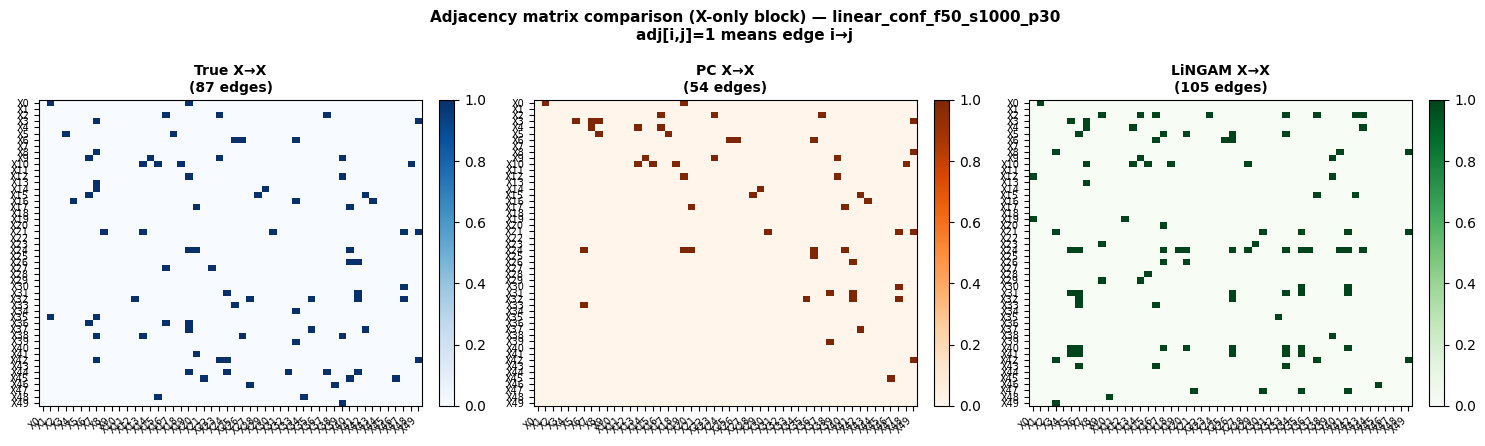

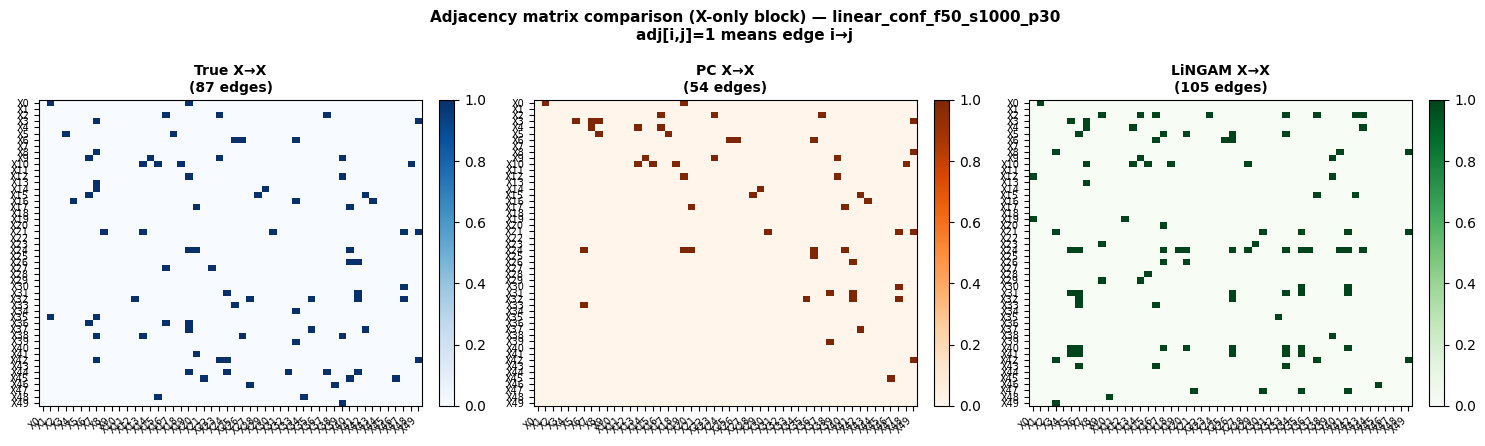

In [25]:
plot_adjacency_comparison(
    true_adj_xx, pc_train_adj_xx, lingam_train_adj_xx,
    feature_names, DATASET, save_dir=PLOTS_DIR,
)
